In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("../0-data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

In [2]:
df_stics = pd.read_csv("../../1-simul_stics/2-outputs/simulations_stics_intercrops.csv")
df_stics["usm"] = df_stics["situation"]
df_stics["faPAR STICS"] = df_stics["raint"] / (0.48 * 0.95 * df_stics["trg_n"])
df_stics = df_stics[df_stics["raint"] != 0.0]
df_stics = df_stics[df_stics["laimax"] != 0.0]
df_stics = df_stics[df_stics["hauteur"] != 0.0]
df_stics

,situation,Date,pla,somupvtsem,laimax,laisen_n,hauteur,raint,trg_n,ilevs,iamfs,ilaxs,densite,demande,lai_n,Plant,Dominance,algorithm,usm,fapar_stics
208,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,2.5D,usm_1,0.000081
209,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,Beer,usm_1,0.000081
212,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,2.5D,usm_1,0.000178
213,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,Beer,usm_1,0.000178
214,usm_1,2018-07-07,sor,181.01837,0.00002,0.00000,0.01528,0.00010,18.9,188,232,282,4.16667,0.01000,0.00002,sorghum,Principal,Beer,usm_1,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41263,usm_9,2018-10-13,sor,1561.63757,4.43769,0.09140,2.49980,7.13167,19.2,188,232,282,11.11111,1.80876,4.38604,sorghum,Principal,Beer,usm_9,0.814564
41264,usm_9,2018-10-14,mai,2216.54102,2.88442,2.93751,2.50000,1.73668,20.7,186,218,240,11.11111,0.69833,0.00000,maize,Associated,2.5D,usm_9,0.183986
41265,usm_9,2018-10-14,mai,2223.13452,2.88022,2.93336,2.50000,1.51072,20.7,186,218,240,11.11111,0.61417,0.00000,maize,Associated,Beer,usm_9,0.160047
41266,usm_9,2018-10-14,sor,1572.56299,4.05810,0.10292,2.49979,7.40045,20.7,188,232,282,11.11111,1.98293,3.99535,sorghum,Principal,2.5D,usm_9,0.784012


In [3]:
from datetime import timedelta, datetime
dates = [] 
current_date = datetime.strptime(min(df_stics["Date"]), "%Y-%m-%d").date()
while current_date <= datetime.strptime(max(df_stics["Date"]), "%Y-%m-%d").date(): 
    dates.append(str(current_date))
    current_date += timedelta(days=1)
steps = {d:s for s,d in enumerate(dates)}

df_stics["step_number"] = df_stics["Date"].map(steps)
df_stics["group"] = df_stics["Plant"]
df_stics["algo"] = df_stics["algorithm"]
df_stics

,situation,Date,pla,somupvtsem,laimax,laisen_n,hauteur,raint,trg_n,ilevs,...,demande,lai_n,Plant,Dominance,algorithm,usm,fapar_stics,step_number,group,algo
208,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,...,0.01000,0.00012,maize,Associated,2.5D,usm_1,0.000081,1,maize,2.5D
209,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,...,0.01000,0.00012,maize,Associated,Beer,usm_1,0.000081,1,maize,Beer
212,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,...,0.01000,0.00025,maize,Associated,2.5D,usm_1,0.000178,2,maize,2.5D
213,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,...,0.01000,0.00025,maize,Associated,Beer,usm_1,0.000178,2,maize,Beer
214,usm_1,2018-07-07,sor,181.01837,0.00002,0.00000,0.01528,0.00010,18.9,188,...,0.01000,0.00002,sorghum,Principal,Beer,usm_1,0.000012,2,sorghum,Beer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41263,usm_9,2018-10-13,sor,1561.63757,4.43769,0.09140,2.49980,7.13167,19.2,188,...,1.80876,4.38604,sorghum,Principal,Beer,usm_9,0.814564,100,sorghum,Beer
41264,usm_9,2018-10-14,mai,2216.54102,2.88442,2.93751,2.50000,1.73668,20.7,186,...,0.69833,0.00000,maize,Associated,2.5D,usm_9,0.183986,101,maize,2.5D
41265,usm_9,2018-10-14,mai,2223.13452,2.88022,2.93336,2.50000,1.51072,20.7,186,...,0.61417,0.00000,maize,Associated,Beer,usm_9,0.160047,101,maize,Beer
41266,usm_9,2018-10-14,sor,1572.56299,4.05810,0.10292,2.49979,7.40045,20.7,188,...,1.98293,3.99535,sorghum,Principal,2.5D,usm_9,0.784012,101,sorghum,2.5D


'\ng = sns.relplot(\n    data=fmri,\n    x="timepoint", y="signal",\n    hue="event", style="event", col="region",\n    height=4, aspect=.7, kind="line"\n)\n(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)\n  .set_axis_labels("Timepoint", "Percent signal change")\n  .set_titles("Region: {col_name} cortex")\n  .tight_layout(w_pad=0))\n'

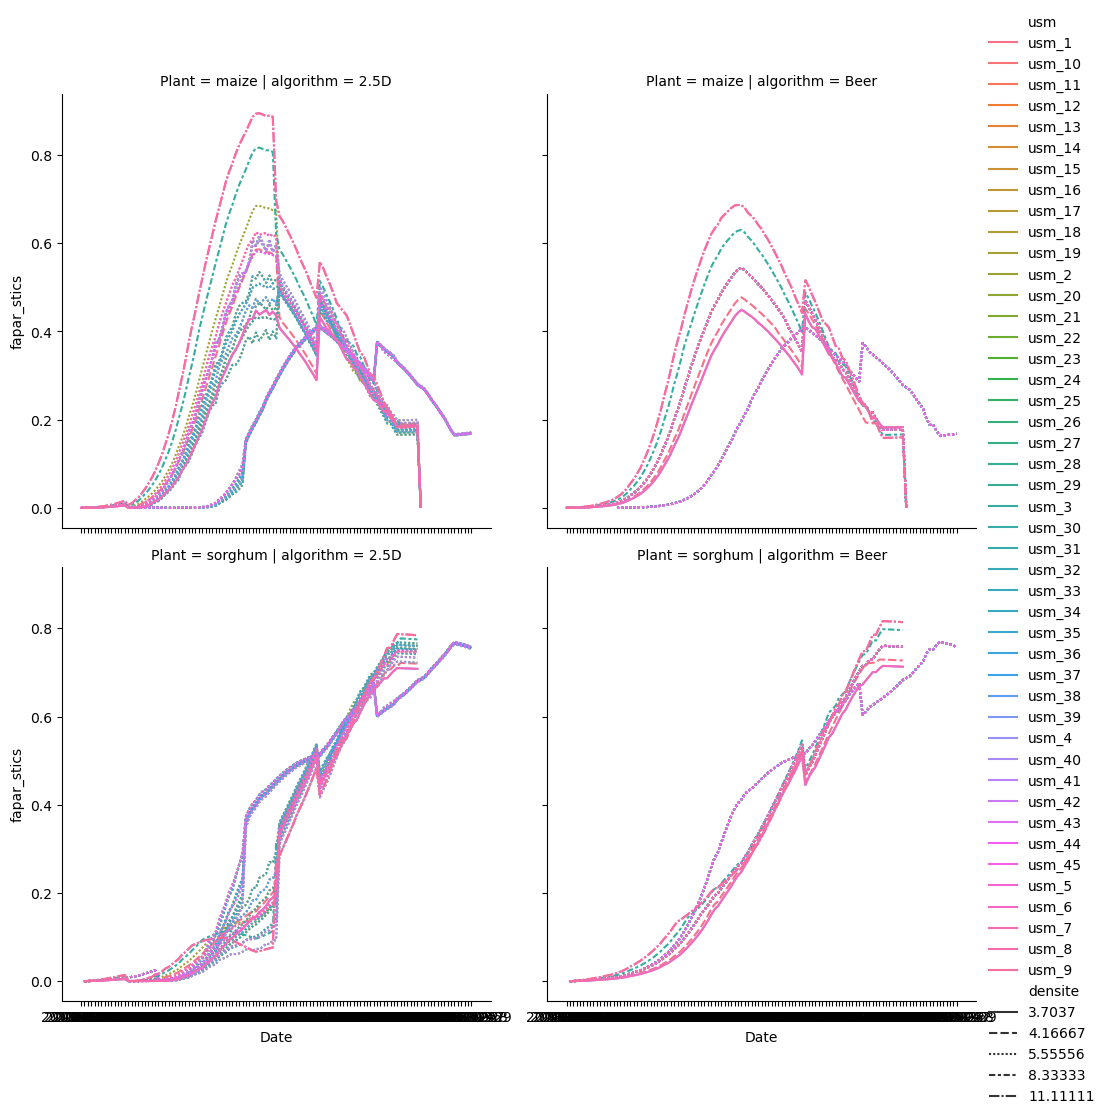

In [4]:
sns.relplot(
    data=df_stics,
    x="Date", 
    y="faPAR STICS",
    hue="usm",
    row="Plant",
    col="algorithm",
    style="densite",
    kind="line",
)

'''
g = sns.relplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="event", style="event", col="region",
    height=4, aspect=.7, kind="line"
)
(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)
  .set_axis_labels("Timepoint", "Percent signal change")
  .set_titles("Region: {col_name} cortex")
  .tight_layout(w_pad=0))
'''

In [5]:
df_doe = pd.read_csv("../../1-simul_stics/2-outputs/doe.csv")

df_doe["usm"] = [f"usm_{i}" for i in range(1,len(df_doe)+1)]

df_doe

,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop,usm
0,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,usm_1
1,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,middle,same,usm_2
2,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,low,same,usm_3
3,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,high,high,one,one,middle,same,usm_4
4,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,middle,middle,one,one,middle,same,usm_5
5,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,low,low,one,one,middle,same,usm_6
6,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,high,high,one,one,middle,same,usm_7
7,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,middle,middle,one,one,middle,same,usm_8
8,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same,usm_9
9,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same,usm_10


In [147]:
directory = Path("../0-data/")

for i,file in enumerate(directory.glob("*.csv")):

    # Read the CSV file
    df = pd.read_csv(file)
    
    # Keep only maize and sorghum
    crop_df = df[df["group"].isin(["maize", "sorghum"])]
    
    # Calculate average fAPAR for each group at each time step
    average_fapar = (
        crop_df
        .groupby(["group", "step_number"], as_index=False)["fapar"]
        # .mean()
        .sum()
        .rename(columns={"fapar": "faPAR"})
    )

    fn = Path(file).stem
    u = re.search(r"usm_\d+", fn).group()
    average_fapar["usm"] = u
    average_fapar["algo"] = "2.5D" if i%2==0 else "Beer"

    if i==0:
        conc_df = average_fapar
    else:
        conc_df = pd.concat([conc_df, average_fapar], ignore_index=True)
        

    # print(average_fapar)

In [148]:
conc_df

,group,step_number,faPAR,usm,algo
0,maize,1,0.000977,usm_10,2.5D
1,maize,2,0.001464,usm_10,2.5D
2,maize,3,0.002019,usm_10,2.5D
3,maize,4,0.002865,usm_10,2.5D
4,maize,5,0.003933,usm_10,2.5D
...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer
18171,sorghum,99,0.911317,usm_9,Beer
18172,sorghum,100,0.911588,usm_9,Beer
18173,sorghum,101,0.911455,usm_9,Beer


In [149]:
merged = pd.merge(conc_df, df_doe, on="usm")

In [150]:
merged

,group,step_number,faPAR,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18171,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18172,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18173,sorghum,101,0.911455,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same


In [151]:
merged = pd.merge(merged, df_stics, on=["usm","step_number","group","algo"])
merged

,group,step_number,faPAR,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,...,ilevs,iamfs,ilaxs,densite,demande,lai_n,Plant,Dominance,algorithm,fapar_stics
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00015,maize,Associated,2.5D,0.000108
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00034,maize,Associated,2.5D,0.000236
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00054,maize,Associated,2.5D,0.000378
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00083,maize,Associated,2.5D,0.000578
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01009,0.00118,maize,Associated,2.5D,0.000828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,sorghum,97,0.911175,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,2.05934,4.41359,sorghum,Principal,Beer,0.815806
17997,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.88394,4.40608,sorghum,Principal,Beer,0.815468
17998,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.83467,4.39598,sorghum,Principal,Beer,0.815014
17999,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.80876,4.38604,sorghum,Principal,Beer,0.814564


In [152]:
dist = {"low":0.2, "middle":0.4, "high":0.8}
n_rows = {"one":1, "low":2, "middle":4, "high":6}

merged["species"] = merged["group"]
merged["DAE"] = merged["step_number"]
merged["design"] = [str(d)[10:] for d in merged["design"]]
merged["interrow_sorghum"] = [dist[i] for i in merged["interrow_distance_principal"]] 
merged["interrow_maize"] = [dist[i] for i in merged["interrow_distance_secondary"]]
merged["intrarow"] = [dist[i] for i in merged["intrarow_distance"]]
merged["n_rows_sorghum"] = [n_rows[i] for i in merged["n_rows_principal"]]
merged["n_rows_maize"] = [n_rows[i] for i in merged["n_rows_secondary"]]
merged["% sorghum"] = [round((s/(s+m))*100,1) for s,m in zip(merged["n_rows_sorghum"],merged["n_rows_maize"])]
merged["density"] = 1/merged["interrow_sorghum"]/merged["intrarow"]
# merged["density_sorghum"] = 1/merged["interrow_sorghum"]/merged["intrarow"]
# merged["density_maize"] = 1/merged["interrow_maize"]/merged["intrarow"]
# merged["nb_plants_sorghum"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_sorghum"] for i in range(len(merged))]
# merged["nb_plants_maize"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_maize"] for i in range(len(merged))]
# merged["width"] = [2 * merged.iloc[i]["interrow_sorghum"] if merged.iloc[i]["design"] == "intercrop mixed" else (merged.iloc[i]["n_rows_sorghum"]-1) * merged.iloc[i]["interrow_sorghum"] + (merged.iloc[i]["n_rows_maize"]-1) * merged.iloc[i]["interrow_maize"] + 2*max(merged.iloc[i]["interrow_sorghum"], merged.iloc[i]["interrow_maize"]) for i in range(len(merged))]
# merged["length"] = [2 * max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) if merged.iloc[i]["design"] == "intercrop mixed" else max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) for i in range(len(merged))]
# merged["domain_area"] = merged["width"] * merged["length"]

merged

,group,step_number,faPAR,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,...,fapar_stics,species,DAE,interrow_sorghum,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,% sorghum,density
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,strips,N-S,...,0.000108,maize,1,0.4,0.4,0.4,6,6,50.0,6.25
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,strips,N-S,...,0.000236,maize,2,0.4,0.4,0.4,6,6,50.0,6.25
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,strips,N-S,...,0.000378,maize,3,0.4,0.4,0.4,6,6,50.0,6.25
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,strips,N-S,...,0.000578,maize,4,0.4,0.4,0.4,6,6,50.0,6.25
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,strips,N-S,...,0.000828,maize,5,0.4,0.4,0.4,6,6,50.0,6.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,sorghum,97,0.911175,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,alternate,E-W,...,0.815806,sorghum,97,0.2,0.2,0.4,1,1,50.0,12.50
17997,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,alternate,E-W,...,0.815468,sorghum,98,0.2,0.2,0.4,1,1,50.0,12.50
17998,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,alternate,E-W,...,0.815014,sorghum,99,0.2,0.2,0.4,1,1,50.0,12.50
17999,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,alternate,E-W,...,0.814564,sorghum,100,0.2,0.2,0.4,1,1,50.0,12.50


In [153]:
merged = merged.drop(columns=["species_id","species_principal","species_secondary","group"])
merged

,step_number,faPAR,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,fapar_stics,species,DAE,interrow_sorghum,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,% sorghum,density
0,1,0.000977,usm_10,2.5D,strips,N-S,middle,middle,high,high,...,0.000108,maize,1,0.4,0.4,0.4,6,6,50.0,6.25
1,2,0.001464,usm_10,2.5D,strips,N-S,middle,middle,high,high,...,0.000236,maize,2,0.4,0.4,0.4,6,6,50.0,6.25
2,3,0.002019,usm_10,2.5D,strips,N-S,middle,middle,high,high,...,0.000378,maize,3,0.4,0.4,0.4,6,6,50.0,6.25
3,4,0.002865,usm_10,2.5D,strips,N-S,middle,middle,high,high,...,0.000578,maize,4,0.4,0.4,0.4,6,6,50.0,6.25
4,5,0.003933,usm_10,2.5D,strips,N-S,middle,middle,high,high,...,0.000828,maize,5,0.4,0.4,0.4,6,6,50.0,6.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,97,0.911175,usm_9,Beer,alternate,E-W,low,low,one,one,...,0.815806,sorghum,97,0.2,0.2,0.4,1,1,50.0,12.50
17997,98,0.911272,usm_9,Beer,alternate,E-W,low,low,one,one,...,0.815468,sorghum,98,0.2,0.2,0.4,1,1,50.0,12.50
17998,99,0.911317,usm_9,Beer,alternate,E-W,low,low,one,one,...,0.815014,sorghum,99,0.2,0.2,0.4,1,1,50.0,12.50
17999,100,0.911588,usm_9,Beer,alternate,E-W,low,low,one,one,...,0.814564,sorghum,100,0.2,0.2,0.4,1,1,50.0,12.50


In [154]:
simultaneous = merged[merged["sowing_date_latest_crop"] == "same"]

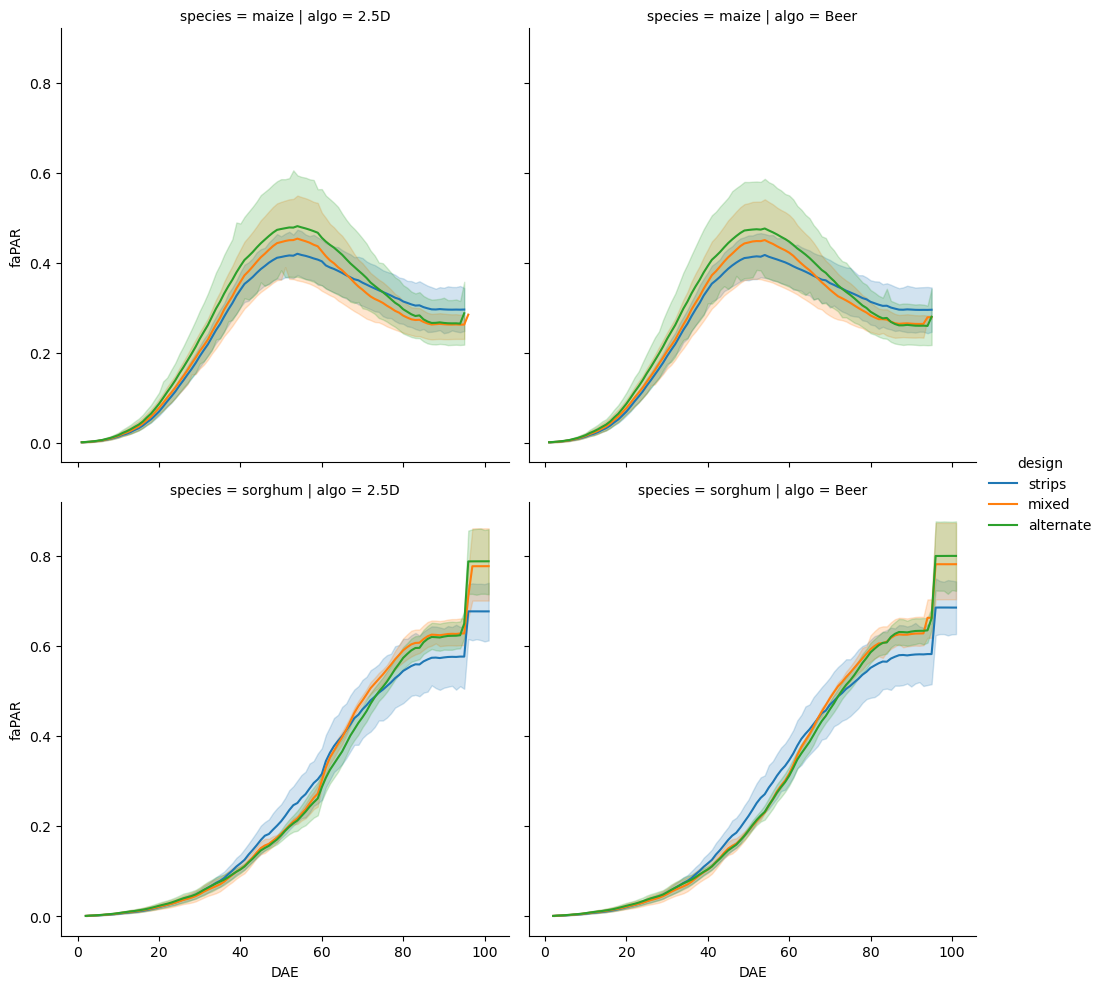

In [155]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR",
    hue="design",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_designs.png')

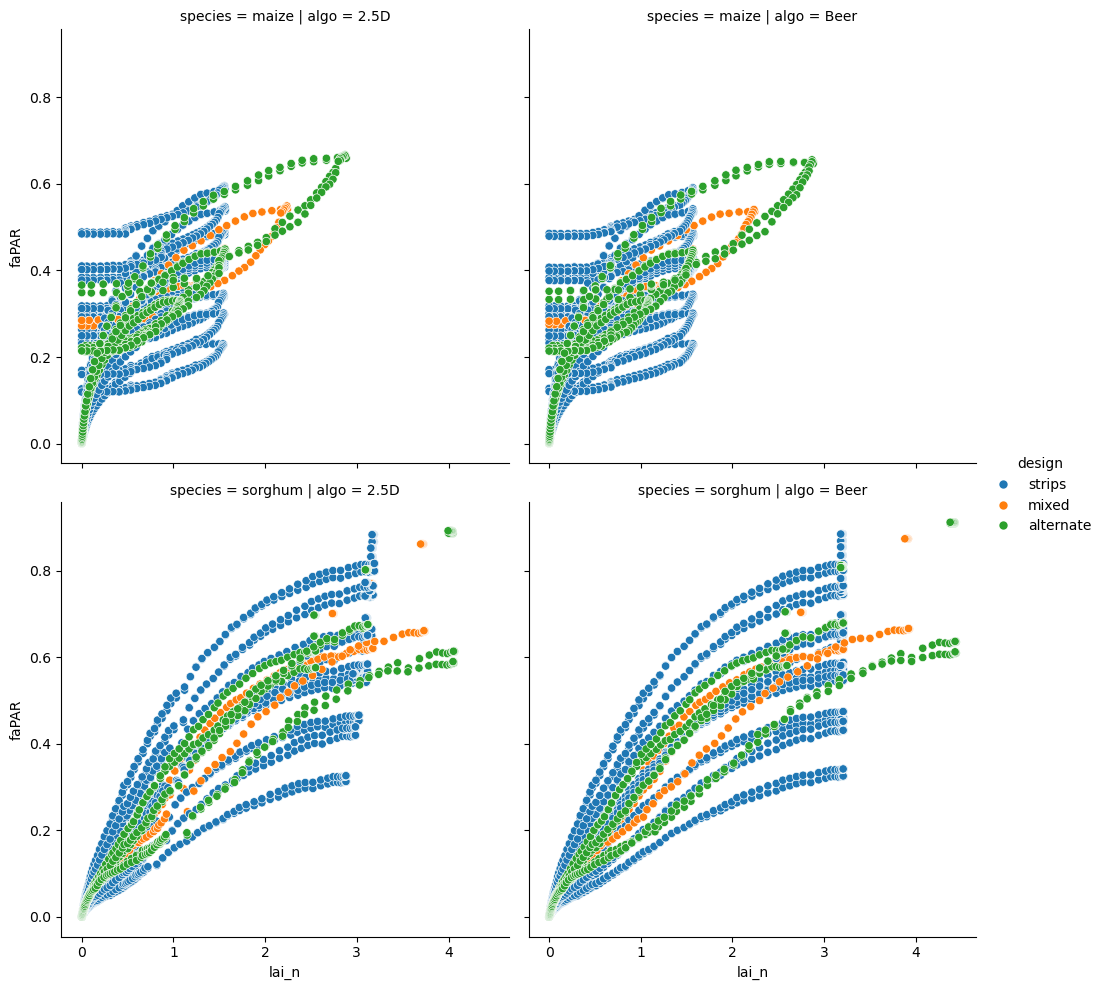

In [156]:
plot = sns.relplot(
    data=simultaneous,
    x="lai_n", 
    y="faPAR",
    hue="design",
    row="species",
    col="algo",
    kind="scatter",
)

plot.savefig('../2-outputs/light_designs_LAI.png')

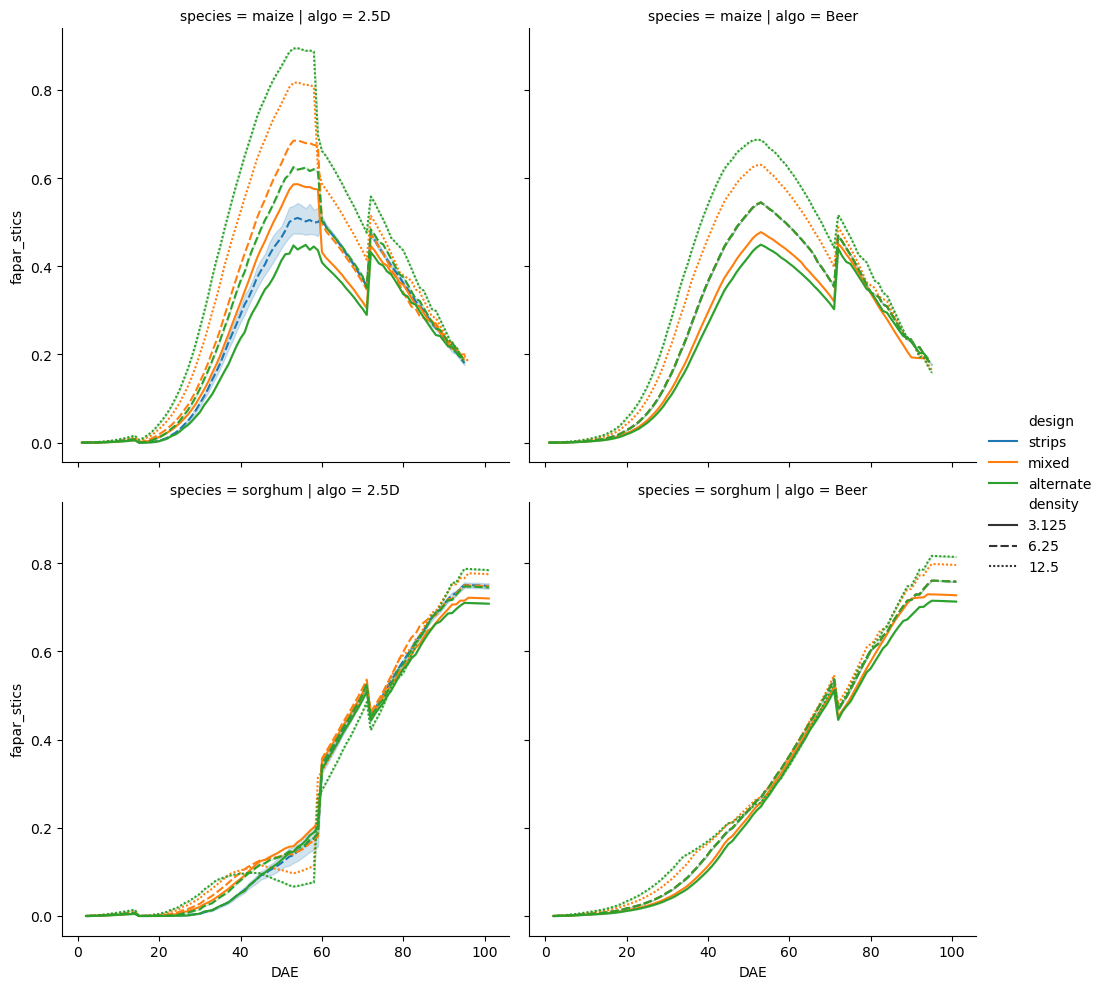

In [188]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR STICS",
    hue="design",
    row="species",
    col="algo",
    style="density",
    kind="line",
)

plot.savefig('../2-outputs/light_stics_designs_density.png')

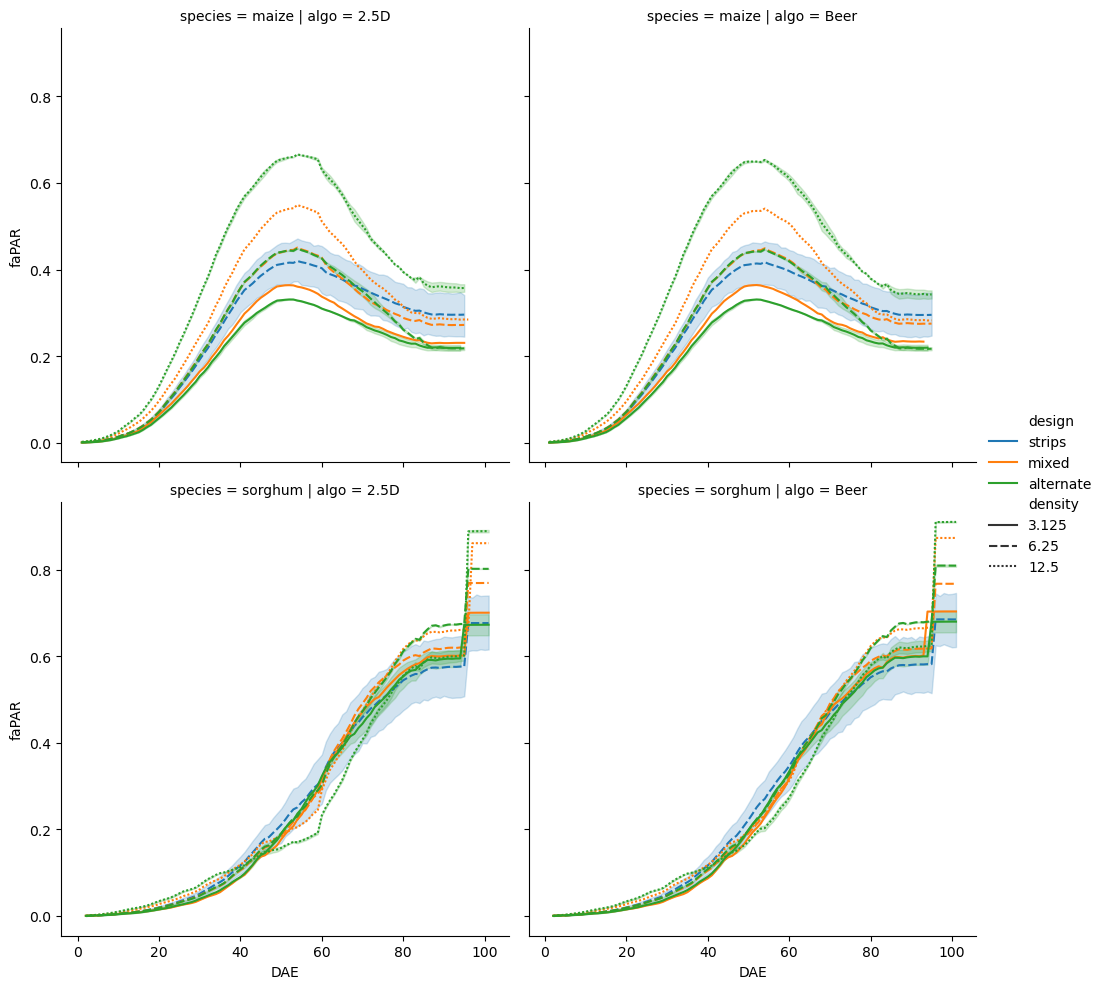

In [157]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR",
    hue="design",
    row="species",
    col="algo",
    style="density",
    kind="line",
)

plot.savefig('../2-outputs/light_designs_density.png')

In [129]:
alt_low_NS = simultaneous[simultaneous["usm"]=="usm_4"]
alt_low_NS_2D = alt_low_NS[alt_low_NS["algo"]=="2.5D"]
alt_low_NS_2D_maize = alt_low_NS_2D.loc[alt_low_NS_2D["species"]=="maize", "faPAR"]
alt_low_NS_2D_sorghum = alt_low_NS_2D.loc[alt_low_NS_2D["species"]=="sorghum", "faPAR"]

mix_low_NS = simultaneous[simultaneous["usm"]=="usm_1"]
mix_low_NS_2D = mix_low_NS[mix_low_NS["algo"]=="2.5D"]
mix_low_NS_2D_maize = mix_low_NS_2D.loc[mix_low_NS_2D["species"]=="maize", "faPAR"]
mix_low_NS_2D_sorghum = mix_low_NS_2D.loc[mix_low_NS_2D["species"]=="sorghum", "faPAR"]

RMSE_m = ((np.array(alt_low_NS_2D_maize) - np.array(mix_low_NS_2D_maize)[:-1]) ** 2).mean() ** .5
RMSE_s = ((np.array(alt_low_NS_2D_sorghum) - np.array(mix_low_NS_2D_sorghum)) ** 2).mean() ** .5
print(f"RMSE alt vs. mix maize low density: {RMSE_m:.3f}")
print(f"RMSE alt vs. mix sorghum low density: {RMSE_s:.3f}")
print(f"RMSE alt vs. mix low density: {np.sqrt(RMSE_s**2+RMSE_m**2):.3f}")

RMSE alt vs. mix maize low density: 0.015
RMSE alt vs. mix sorghum low density: 0.025
RMSE alt vs. mix low density: 0.029


In [130]:
alt_middle_NS = simultaneous[simultaneous["usm"]=="usm_5"]
alt_middle_NS_2D = alt_middle_NS[alt_middle_NS["algo"]=="2.5D"]
alt_middle_NS_2D_maize = alt_middle_NS_2D.loc[alt_middle_NS_2D["species"]=="maize", "faPAR"]
alt_middle_NS_2D_sorghum = alt_middle_NS_2D.loc[alt_middle_NS_2D["species"]=="sorghum", "faPAR"]

mix_middle_NS = simultaneous[simultaneous["usm"]=="usm_2"]
mix_middle_NS_2D = mix_middle_NS[mix_middle_NS["algo"]=="2.5D"]
mix_middle_NS_2D_maize = mix_middle_NS_2D.loc[mix_middle_NS_2D["species"]=="maize", "faPAR"]
mix_middle_NS_2D_sorghum = mix_middle_NS_2D.loc[mix_middle_NS_2D["species"]=="sorghum", "faPAR"]

RMSE_m = ((np.array(alt_middle_NS_2D_maize) - np.array(mix_middle_NS_2D_maize)) ** 2).mean() ** .5
RMSE_s = ((np.array(alt_middle_NS_2D_sorghum) - np.array(mix_middle_NS_2D_sorghum)) ** 2).mean() ** .5
print(f"RMSE alt vs. mix maize low density: {RMSE_m:.3f}")
print(f"RMSE alt vs. mix sorghum low density: {RMSE_s:.3f}")
print(f"RMSE alt vs. mix low density: {np.sqrt(RMSE_s**2+RMSE_m**2):.3f}")

RMSE alt vs. mix maize low density: 0.020
RMSE alt vs. mix sorghum low density: 0.022
RMSE alt vs. mix low density: 0.029


In [131]:
alt_high_NS = simultaneous[simultaneous["usm"]=="usm_6"]
alt_high_NS_2D = alt_high_NS[alt_high_NS["algo"]=="2.5D"]
alt_high_NS_2D_maize = alt_high_NS_2D.loc[alt_high_NS_2D["species"]=="maize", "sum_fapar"]
alt_high_NS_2D_sorghum = alt_high_NS_2D.loc[alt_high_NS_2D["species"]=="sorghum", "sum_fapar"]

mix_high_NS = simultaneous[simultaneous["usm"]=="usm_3"]
mix_high_NS_2D = mix_high_NS[mix_high_NS["algo"]=="2.5D"]
mix_high_NS_2D_maize = mix_high_NS_2D.loc[mix_high_NS_2D["species"]=="maize", "sum_fapar"]
mix_high_NS_2D_sorghum = mix_high_NS_2D.loc[mix_high_NS_2D["species"]=="sorghum", "sum_fapar"]

RMSE_m = ((np.array(alt_high_NS_2D_maize) - np.array(mix_high_NS_2D_maize)[:-1]) ** 2).mean() ** .5
RMSE_s = ((np.array(alt_high_NS_2D_sorghum) - np.array(mix_high_NS_2D_sorghum)) ** 2).mean() ** .5
print(f"RMSE alt vs. mix maize low density: {RMSE_m:.3f}")
print(f"RMSE alt vs. mix sorghum low density: {RMSE_s:.3f}")
print(f"RMSE alt vs. mix low density: {np.sqrt(RMSE_s**2+RMSE_m**2):.3f}")

RMSE alt vs. mix maize low density: 0.089
RMSE alt vs. mix sorghum low density: 0.043
RMSE alt vs. mix low density: 0.099


In [14]:
simultaneous

,step_number,sum_fapar,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,1,0.000977,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000509
1,2,0.001464,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000763
2,3,0.002019,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001052
3,4,0.002865,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001492
4,5,0.003933,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,98,0.911272,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695449
18171,99,0.911317,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695729
18172,100,0.911588,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.697423
18173,101,0.911455,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.696592


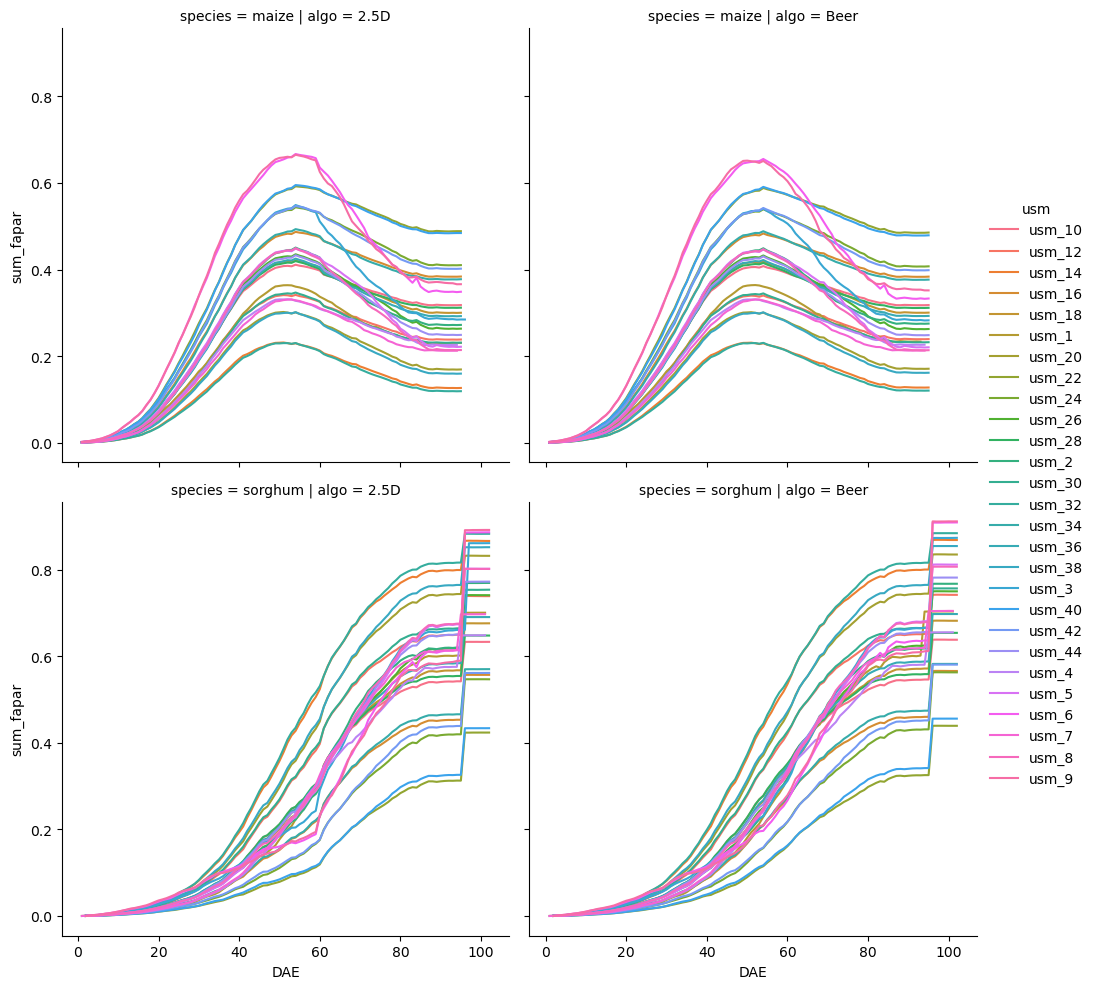

In [15]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR",
    hue="usm",
    row="species",
    col="algo",
    kind="line",
)

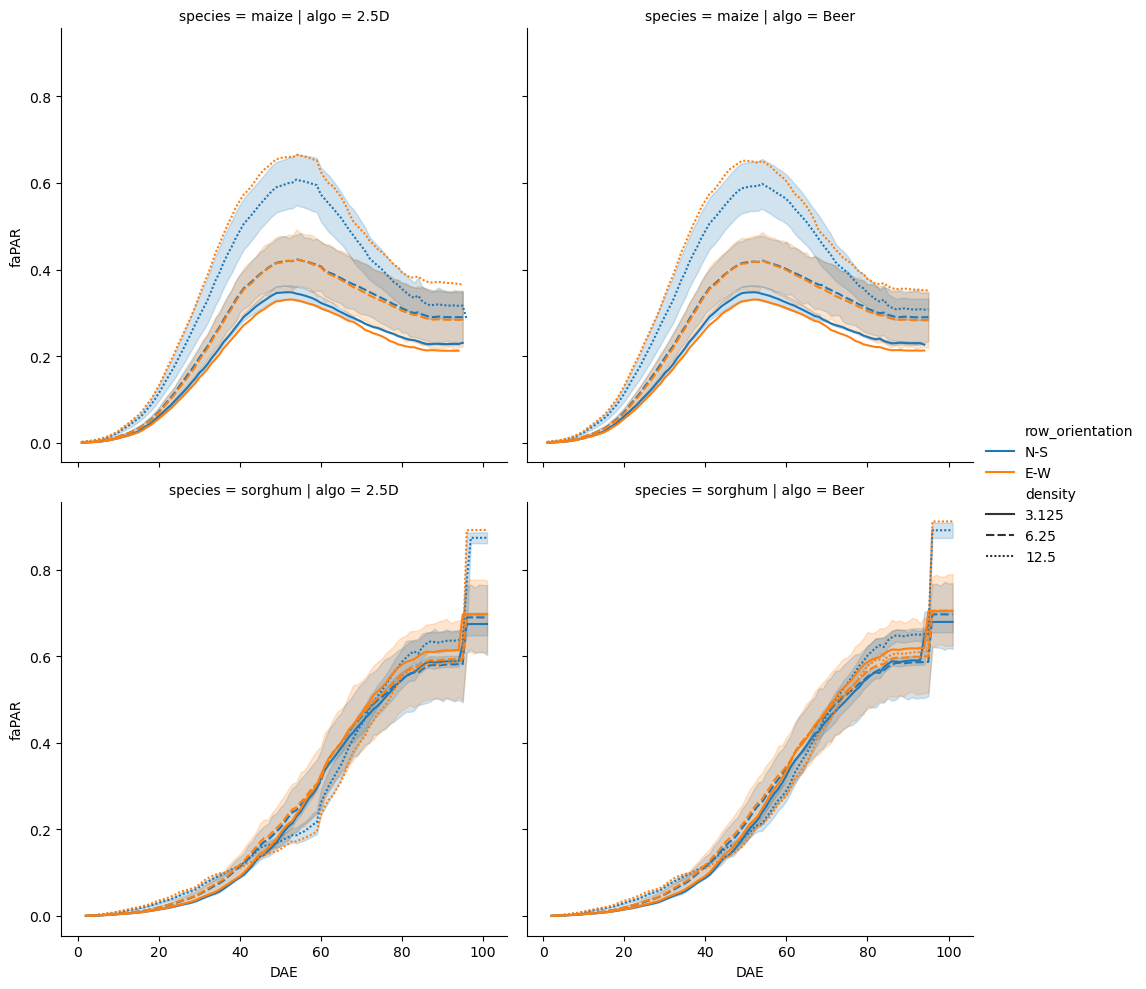

In [158]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR",
    hue="row_orientation",
    row="species",
    col="algo",
    style="density",
    kind="line",
)

plot.savefig('../2-outputs/light_orientation.png')

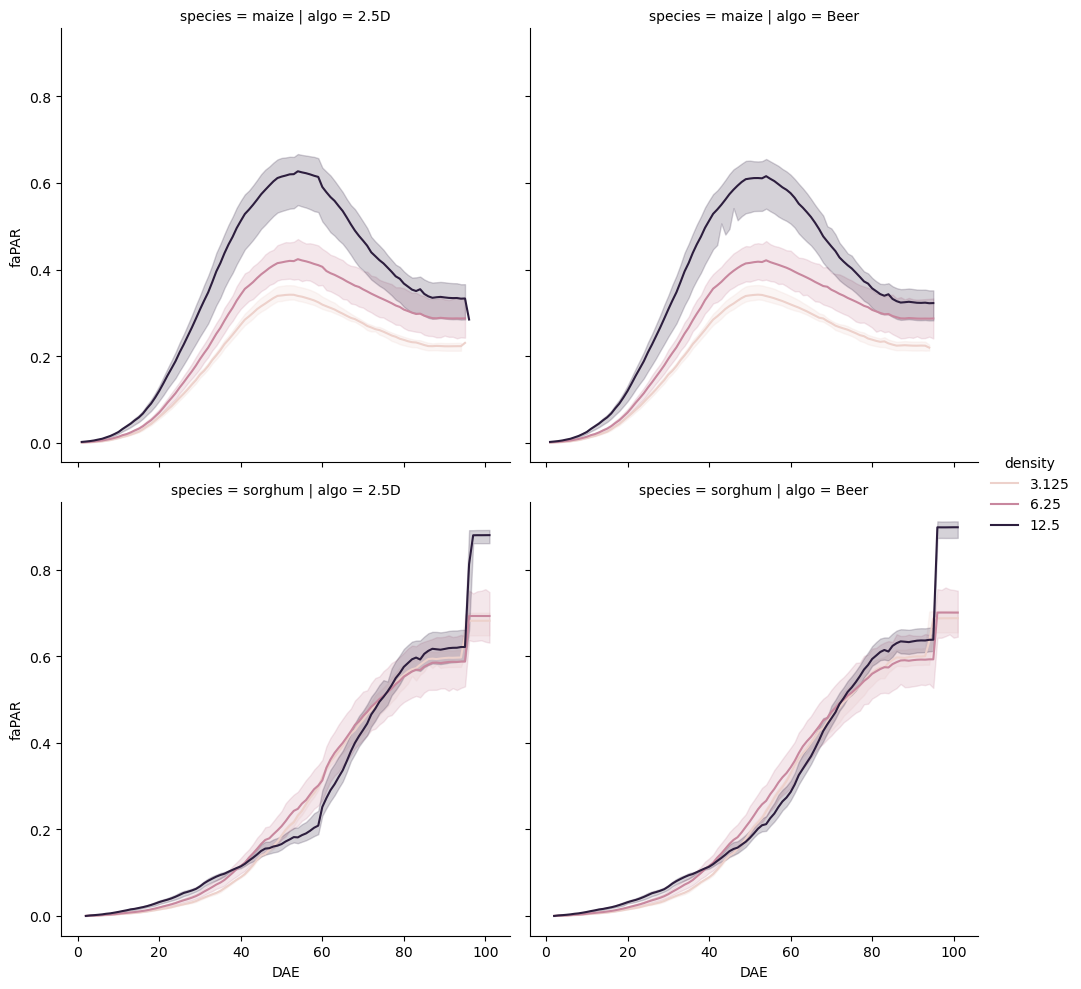

In [159]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="faPAR",
    hue="density",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_density.png')

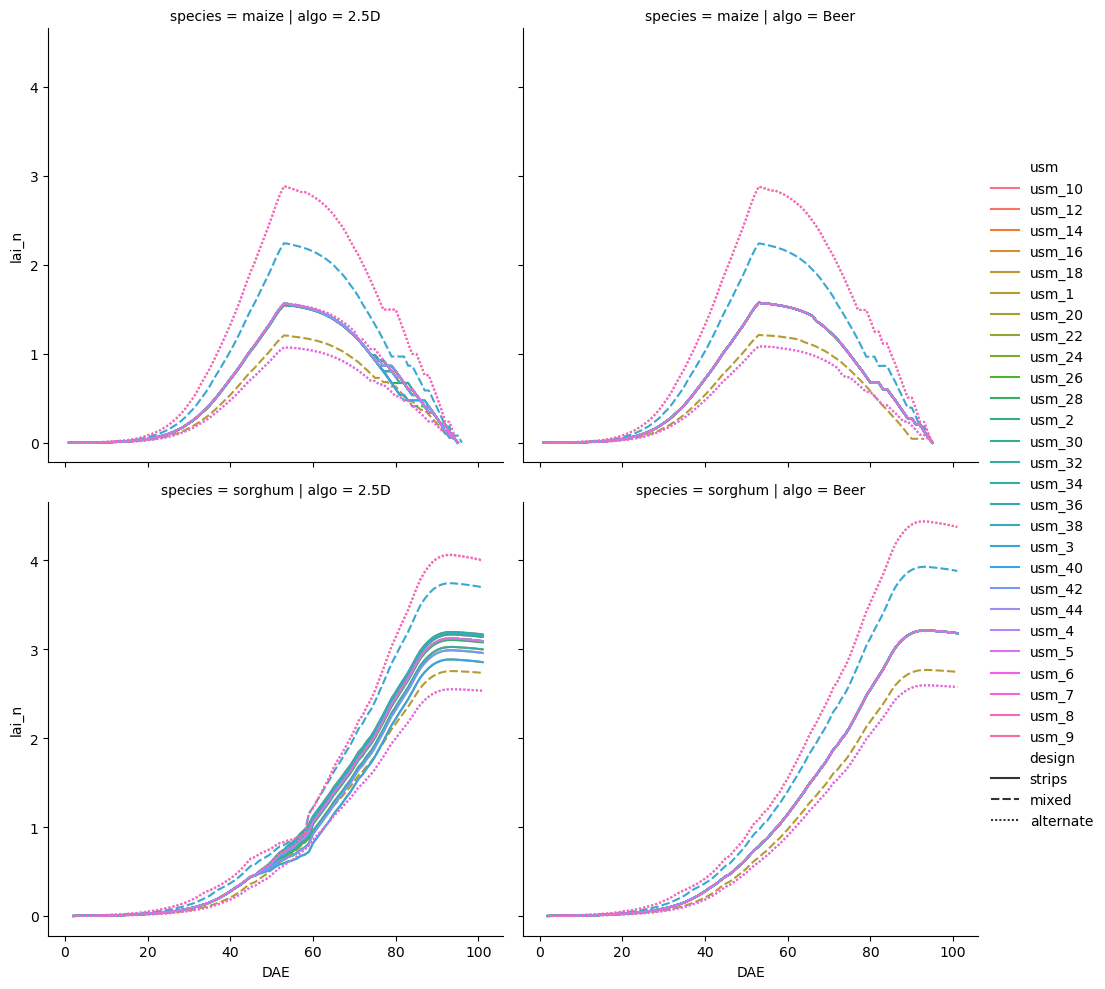

In [186]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="lai_n",
    hue="usm",
    row="species",
    col="algo",
    kind="line",
    style="design"
)

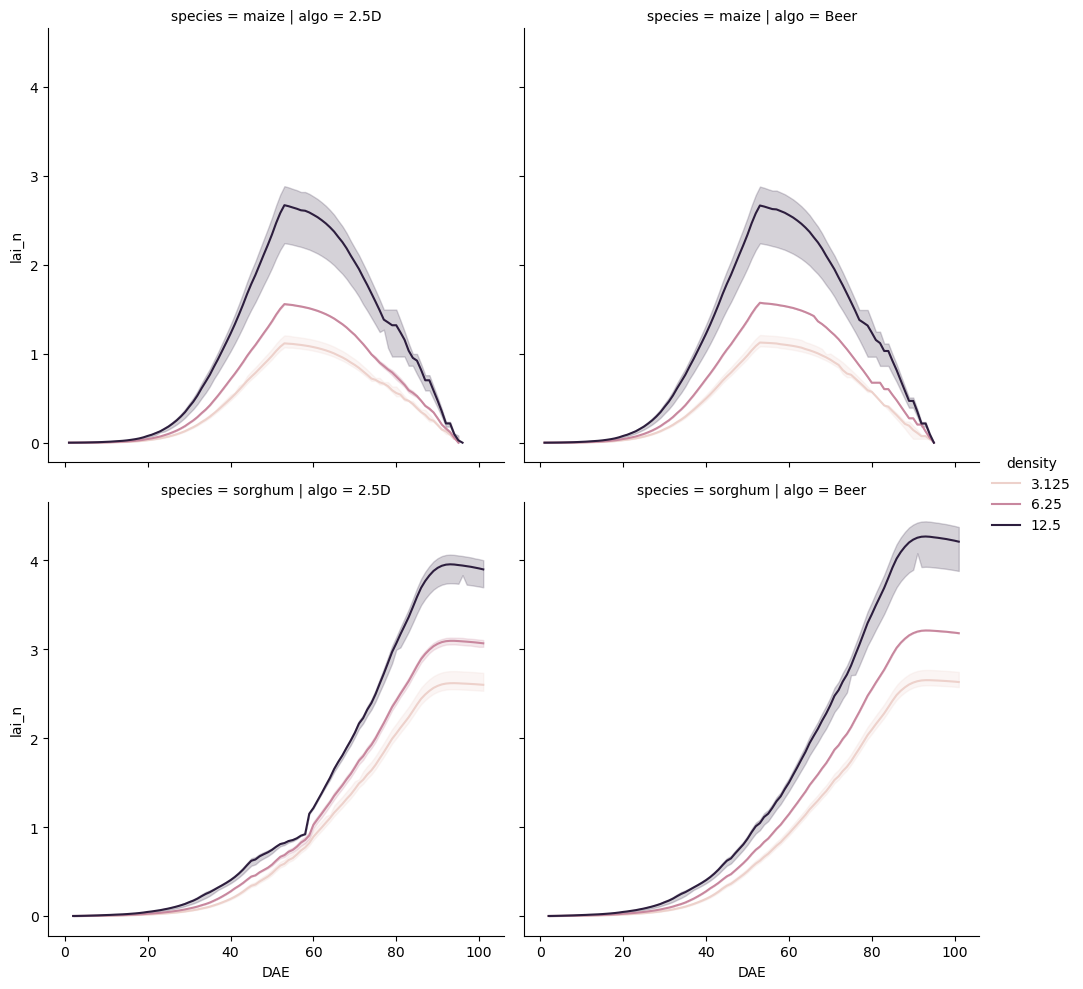

In [182]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="lai_n",
    hue="density",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/LAI.png')

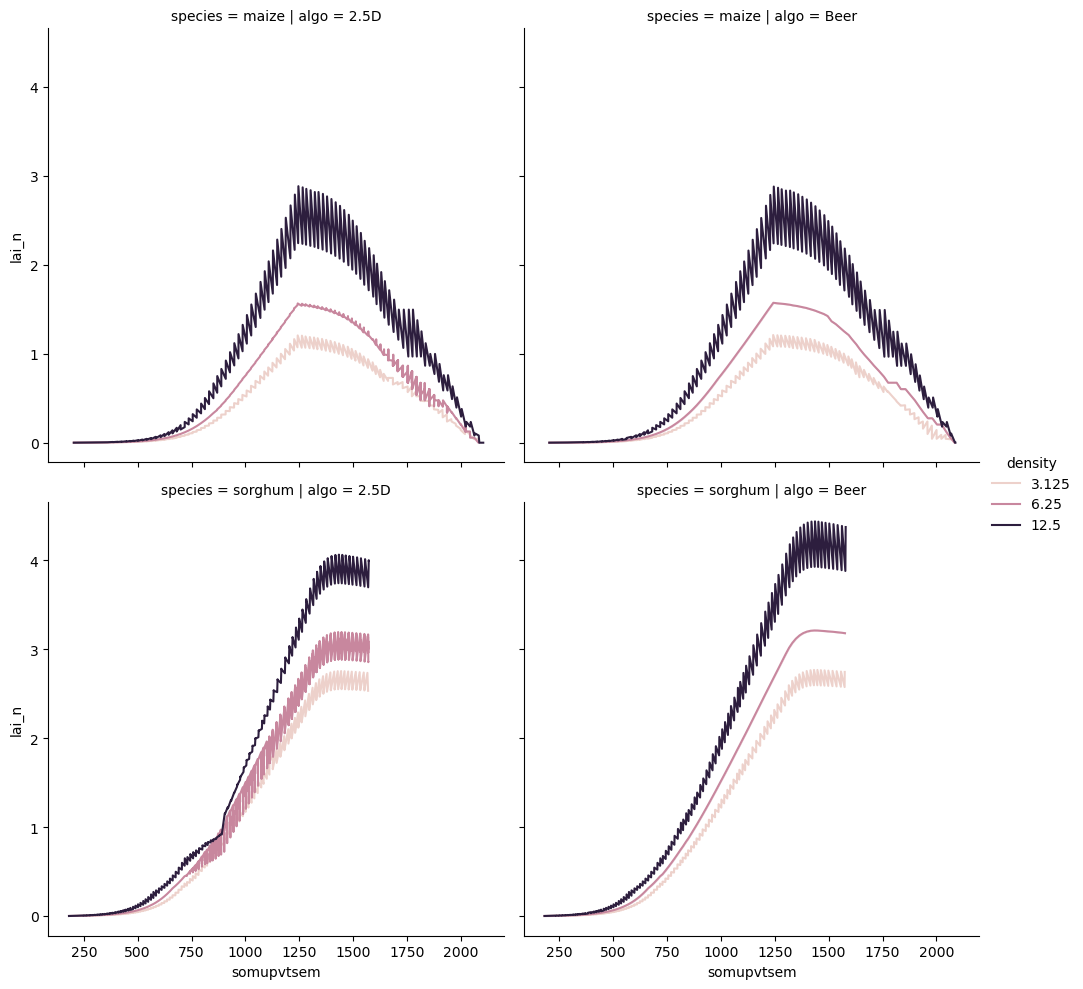

In [190]:
plot = sns.relplot(
    data=simultaneous,
    x="somupvtsem", 
    y="lai_n",
    hue="density",
    row="species",
    col="algo",
    kind="line",
)

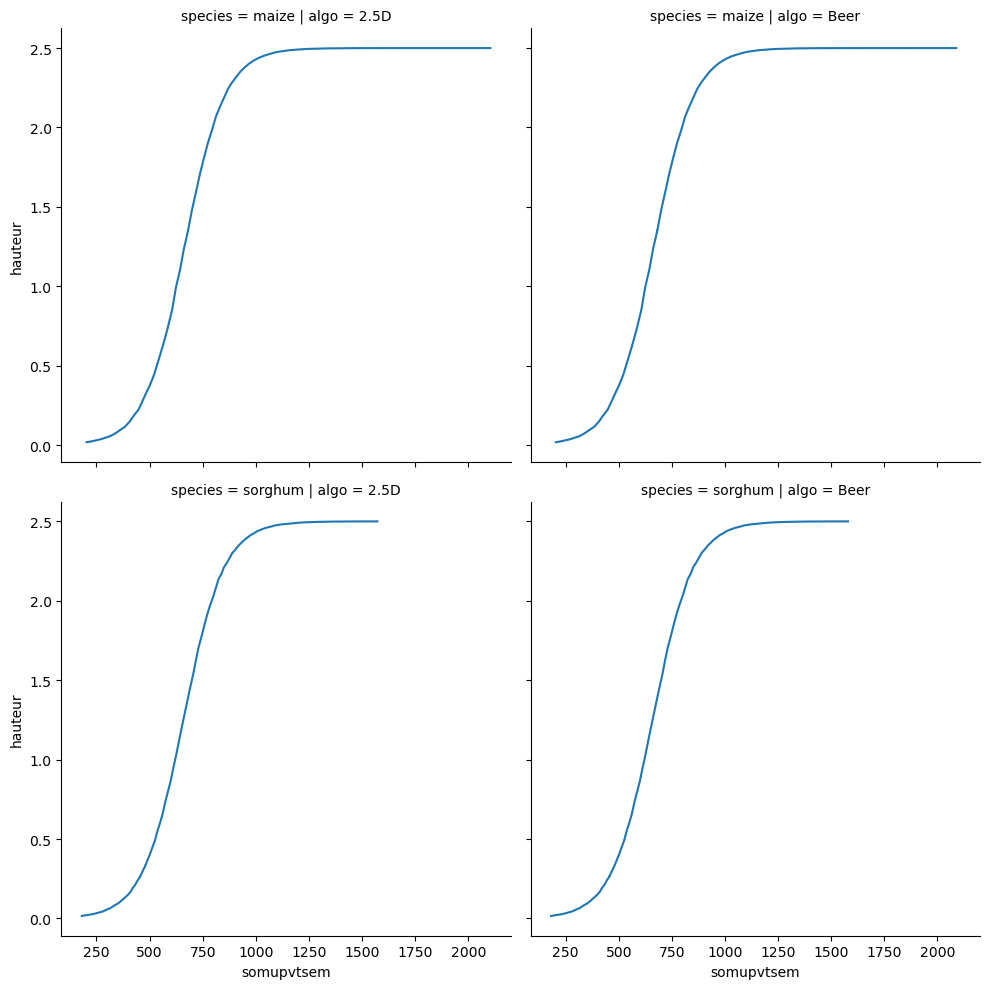

In [189]:
plot = sns.relplot(
    data=simultaneous,
    x="somupvtsem", 
    y="hauteur",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/height.png')

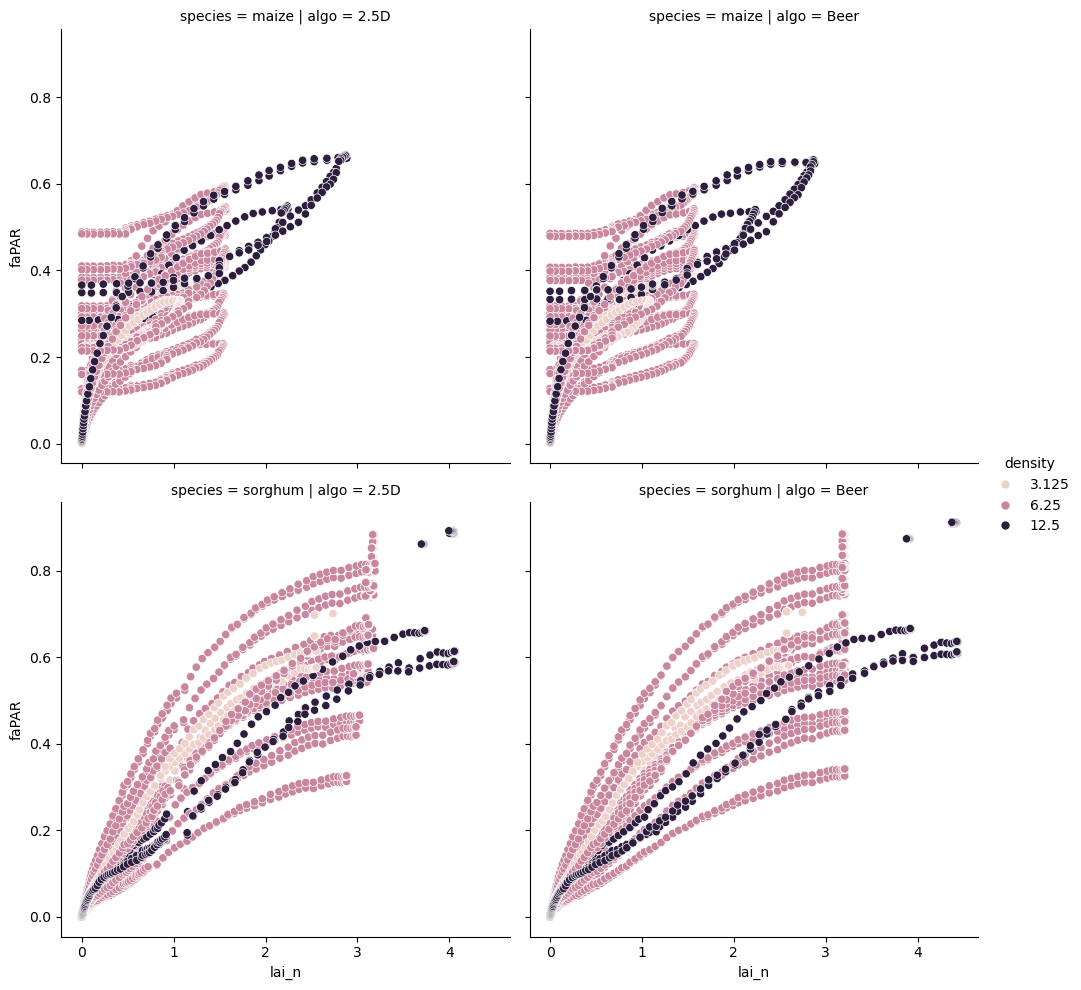

In [161]:
plot = sns.relplot(
    data=simultaneous,
    x="lai_n", 
    y="faPAR",
    hue="density",
    row="species",
    col="algo",
    kind="scatter",
)

plot.savefig('../2-outputs/light_density_LAI.png')

In [14]:
strips = merged[merged["design"] == "intercrop strips"]

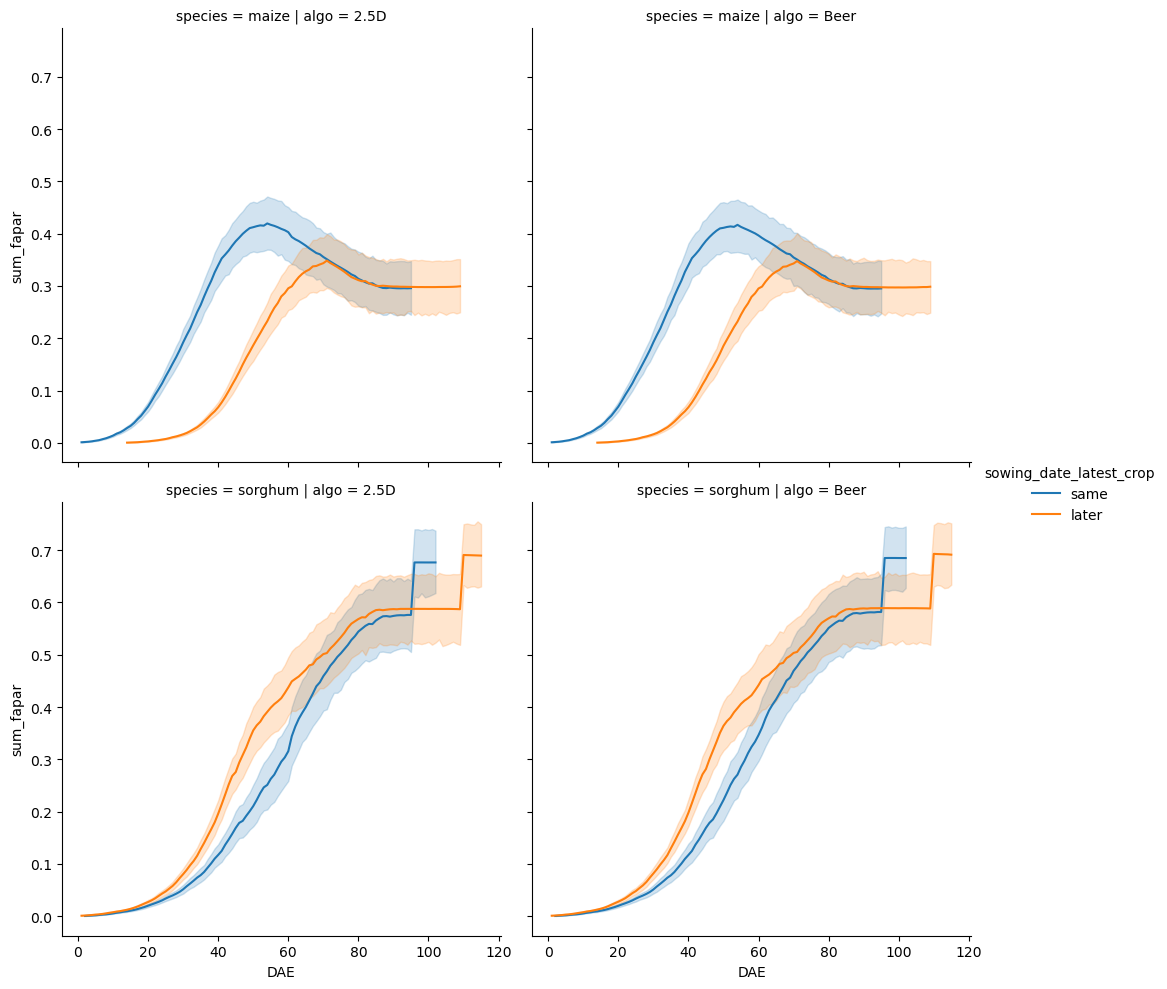

In [20]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_sowing_date.png')

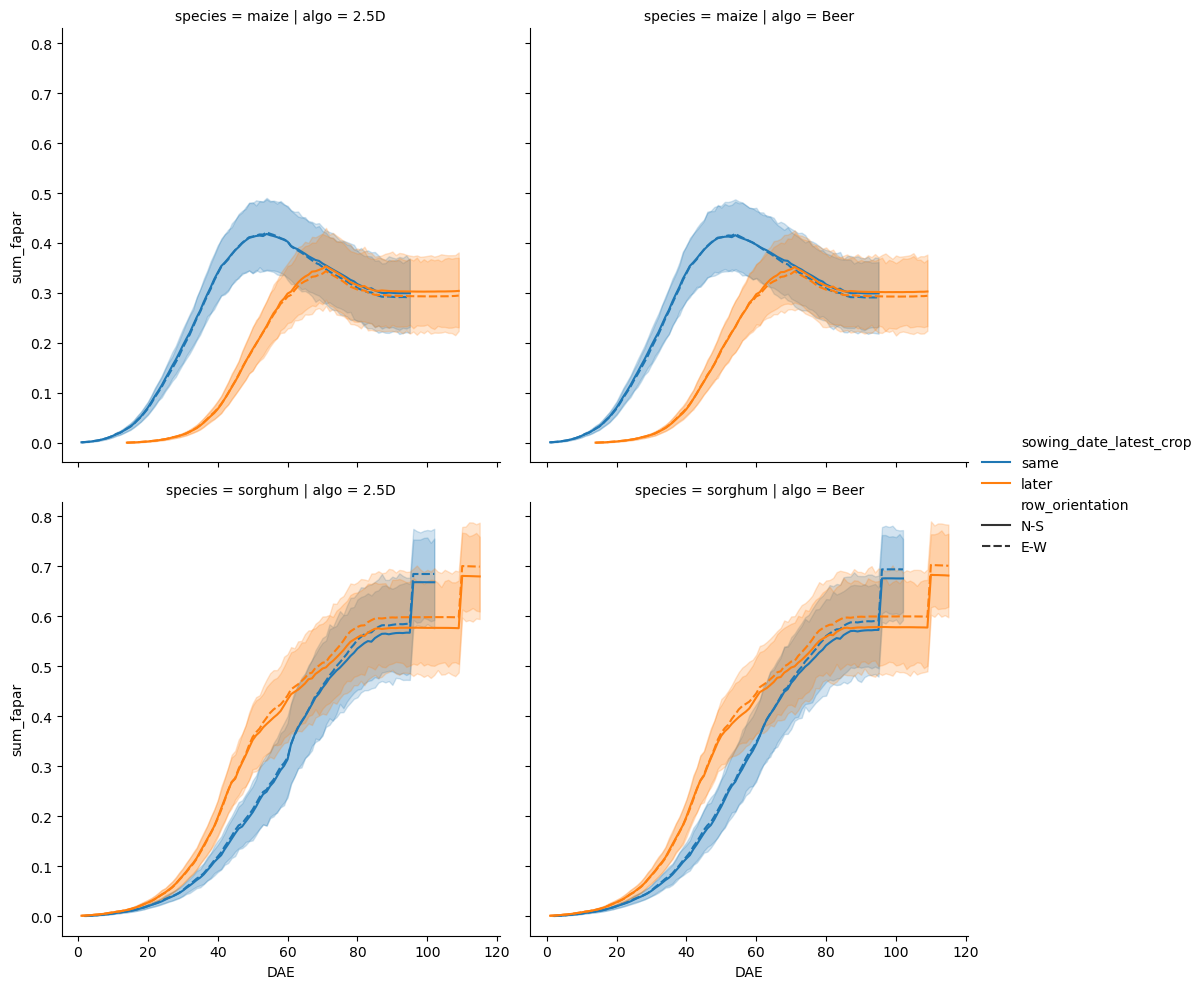

In [21]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    style="row_orientation",
    row="species",
    col="algo",
    kind="line",
)

In [162]:
from sklearn.linear_model import LinearRegression

df = simultaneous.copy()
df["cum_aPAR_3D"] = np.nan
df["cum_aPAR_stics"] = np.nan
df["regression"] = np.nan
df["reference"] = np.nan
df["abs_difference"] = np.nan

'''
group_cols = ["species", "algo", "usm"]

for _, group in df.groupby(group_cols):

    # Sort if the cumulative sum depends on an ordering variable
    group = group.sort_values("sum_fapar")  

    # Cumulative sums
    x_cum = group["sum_fapar"].cumsum()
    y_cum = group["fapar_stics"].cumsum()

    # Final cumulative values
    x_last = x_cum.iloc[-1]
    y_last = y_cum.iloc[-1]

    # Straight line from (0, 0) to (x_last, y_last)
    slope = y_last / x_last

    # Reference y for every cumulative x
    y_reference = slope * x_cum

    # Store results
    df.loc[group.index, "cum_aPAR_3D"] = x_cum
    df.loc[group.index, "cum_aPAR_stics"] = y_cum
    df.loc[group.index, "reference"] = y_reference
    # df.loc[group.index, "abs_difference"] = (y_last - y_reference).abs()

# Absolute difference / residual
df["SEu"] = (df["cum_aPAR_stics"] - df["reference"]) ** 2
# df["SEs"] = (df["sum_fapar"] - df["reference"]) ** 2

rrmse = {}
for u in [f"usm_{i}" for i in range(1,46)]:
    rrmse[u] = {}
    for a in ["2.5D", "Beer"]:
        rrmse[u][a] = {}
        for s in ["maize", "sorghum"]:
            df_tmp = df[(df["usm"]==u) & (df["algo"]==a) & (df["species"]==s)]
            if np.array(df_tmp["SEu"]).size > 0:
                RMSEu = (np.array(df_tmp["SEu"])[-1]) ** .5 
                rRMSEu = RMSEu / np.array(df_tmp["cum_aPAR_3D"])[-1]
                # RMSEs = np.array(df_tmp["SEs"]).mean() ** .5 
                # rRMSEs = (RMSEs / np.array(df_tmp["sum_fapar"]).std())
                rrmse[u][a][s] = {"rRMSEu":round(rRMSEu,3)} #, "rRMSEs":round(rRMSEs,3)}
'''

# Fit one regression per curve
for (algo, species, usm), group in df.groupby(["algo", "species", "usm"]):
    X = group[["faPAR"]]
    y = group["faPAR STICS"]

    model = LinearRegression().fit(X, y)
    df.loc[group.index, "regression"] = model.predict(X)

# Absolute difference / residual
df["SEu"] = (df["faPAR STICS"] - df["regression"]) ** 2
df["SEs"] = (df["faPAR"] - df["regression"]) ** 2

rrmse = {}
for u in [f"usm_{i}" for i in range(1,46)]:
    rrmse[u] = {}
    for a in ["2.5D", "Beer"]:
        rrmse[u][a] = {}
        for s in ["maize", "sorghum"]:
            df_tmp = df[(df["usm"]==u) & (df["algo"]==a) & (df["species"]==s)]
            RMSEu = np.array(df_tmp["SEu"]).mean() ** .5 
            RMSEu_std = (RMSEu / np.array(df_tmp["faPAR"]).std())
            RMSEs = np.array(df_tmp["SEs"]).mean() ** .5 
            RMSEs_std = (RMSEs / np.array(df_tmp["faPAR"]).std())
            RMSE = np.sqrt(RMSEs**2 + RMSEu**2)
            rRMSE = RMSE / np.array(df_tmp["faPAR"]).mean()
            rrmse[u][a][s] = {"RMSE": round(RMSE,3), 
                              "rRMSE": round(rRMSE,3), 
                              "RMSEu":round(RMSEu,3), 
                              "RMSEs":round(RMSEs,3), 
                              "RMSEu / std_3D":round(RMSEu_std,3), 
                              "RMSEs / std_3D":round(RMSEs_std,3)}

C:\Users\cheriere\AppData\Local\Temp\ipykernel_5864\336160559.py:76: RuntimeWarning: Mean of empty slice.
  RMSEu = np.array(df_tmp["SEu"]).mean() ** .5
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\cheriere\AppData\Local\Temp\ipykernel_5864\336160559.py:78: RuntimeWarning: Me

In [163]:
rows = []

for u, usms in rrmse.items():
    for a, algos in usms.items():
        for s, r in algos.items():
                rows.append({
                    "usm": u,
                    "algo": a,
                    "species": s,
                    "RMSE": r["RMSE"],
                    "RMSE_intercrop": np.sqrt(np.array([sp["RMSE"]**2 for sp in algos.values()]).sum()),
                    "rRMSE_intercrop": np.sqrt(np.array([sp["rRMSE"]**2 for sp in algos.values()]).sum()),
                    "RMSEu": r["RMSEu"],
                    "RMSEs": r["RMSEs"],
                    "RMSEu / std_3D": r["RMSEu / std_3D"],
                    "RMSEs / std_3D": r["RMSEs / std_3D"],
                    "RMSEu_intercrop / std_3D": np.sqrt(np.array([sp["RMSEu / std_3D"]**2 for sp in algos.values()]).sum()),
                    "RMSEs_intercrop / std_3D": np.sqrt(np.array([sp["RMSEs / std_3D"]**2 for sp in algos.values()]).sum()),
                })

df_rrmse = pd.DataFrame(rows)
df_rrmse = pd.merge(df_rrmse, df_doe[["usm","design"]], on=["usm"])
df_rrmse["design"] = [str(d)[10:] for d in df_rrmse["design"]]
df_rrmse = pd.merge(df_rrmse, merged[["usm","% sorghum","density","row_orientation"]], on=["usm"]).drop_duplicates()
df_rrmse

,usm,algo,species,RMSE,RMSE_intercrop,rRMSE_intercrop,RMSEu,RMSEs,RMSEu / std_3D,RMSEs / std_3D,RMSEu_intercrop / std_3D,RMSEs_intercrop / std_3D,design,% sorghum,density,row_orientation
0,usm_1,2.5D,maize,0.098,0.105109,0.487922,0.058,0.079,0.490,0.660,0.506442,0.665074,mixed,50.0,3.125,N-S
388,usm_1,2.5D,sorghum,0.038,0.105109,0.487922,0.032,0.020,0.128,0.082,0.506442,0.665074,mixed,50.0,3.125,N-S
776,usm_1,Beer,maize,0.070,0.080623,0.361884,0.048,0.051,0.397,0.419,0.413600,0.432447,mixed,50.0,3.125,N-S
1164,usm_1,Beer,sorghum,0.040,0.080623,0.361884,0.029,0.027,0.116,0.107,0.413600,0.432447,mixed,50.0,3.125,N-S
1552,usm_2,2.5D,maize,0.098,0.107838,0.415235,0.064,0.074,0.433,0.505,0.461616,0.509692,mixed,50.0,6.250,N-S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69950,usm_44,Beer,sorghum,0.029,0.068447,0.271317,0.026,0.013,0.100,0.048,0.304867,0.332483,strips,50.0,6.250,E-W
70340,usm_45,2.5D,maize,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,strips,50.0,6.250,E-W
70756,usm_45,2.5D,sorghum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,strips,50.0,6.250,E-W
71172,usm_45,Beer,maize,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,strips,50.0,6.250,E-W


In [164]:
from matplotlib.patches import Wedge

def arrange_sns_plot(plot, xlim=1.6, ylim=1.6):
    for ax in plot.axes.flat:
        ax.axline((0, 0), slope=1, color="grey", linestyle="--")
        ax.set_xlim([0,xlim])
        ax.set_ylim([0,ylim])
        
        wedge = Wedge(
            center=(0, 0),
            r=0.5,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)
    
        wedge = Wedge(
            center=(0, 0),
            r=0.6,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)
    
        wedge = Wedge(
            center=(0, 0),
            r=0.7,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)

In [165]:
def label_point(x, y, val, algo, plot):
    for ax, algo_value in zip(plot.axes.flat, plot.col_names):

        a = pd.DataFrame({
            "x": x,
            "y": y,
            "val": val,
            "algo": algo,
        })
        
        # Keep only points for this algo
        subset = a[a["algo"] == algo_value]

        for _, point in subset.iterrows():

            if point["x"]**2 + point["y"]**2 >= 0.7**2:
                ax.text(
                    point["x"] + 0.03,
                    point["y"] - 0.02,
                    str(point["val"])[-2:],
                    fontsize=8
                )

2.5D usm_1 0.105
2.5D usm_2 0.108
2.5D usm_3 0.123
2.5D usm_6 0.119
2.5D usm_9 0.123
2.5D usm_10 0.11
2.5D usm_12 0.11
Beer usm_12 0.11
2.5D usm_14 0.191
Beer usm_14 0.214
2.5D usm_16 0.141
Beer usm_16 0.142
2.5D usm_20 0.149
Beer usm_20 0.152
2.5D usm_22 0.224
Beer usm_22 0.248
2.5D usm_24 0.159
Beer usm_24 0.172
2.5D usm_28 0.106
2.5D usm_30 0.112
Beer usm_30 0.111
2.5D usm_32 0.198
Beer usm_32 0.22
2.5D usm_34 0.135
Beer usm_34 0.134
2.5D usm_38 0.157
Beer usm_38 0.16
2.5D usm_40 0.218
Beer usm_40 0.24
2.5D usm_42 0.15
Beer usm_42 0.161


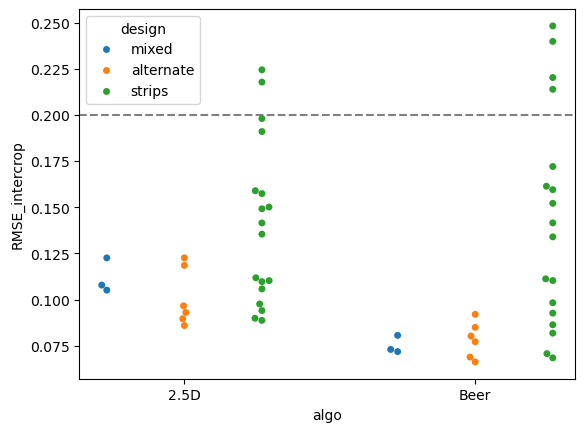

In [167]:
df_tmp = df_rrmse.drop_duplicates(["usm","RMSE_intercrop"])

plot = sns.swarmplot(
    data=df_tmp,
    x="algo", 
    y="RMSE_intercrop",
    hue="design",
    dodge=True
)

plot.axline((0, 0.2), slope=0, color="grey", linestyle="--")

for _, point in df_tmp.iterrows():

            if point["RMSE_intercrop"] >= 0.1:
                print(point["algo"], point["usm"], round(point["RMSE_intercrop"],3))
                
plt.savefig('../2-outputs/RMSE.png', dpi=1000)

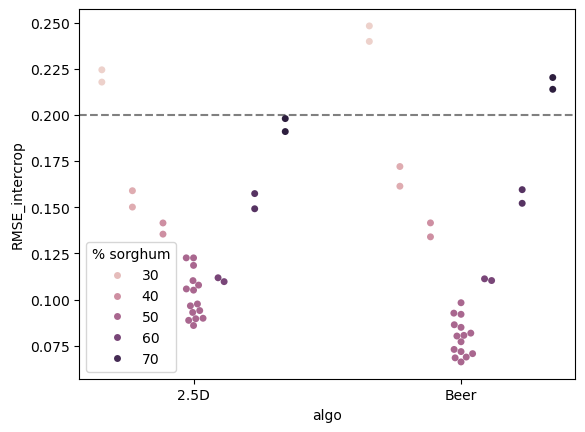

In [168]:
plot = sns.swarmplot(
    data=df_tmp,
    x="algo", 
    y="RMSE_intercrop",
    hue="% sorghum",
    dodge=True
)

plot.axline((0, 0.2), slope=0, color="grey", linestyle="--")
                
plt.savefig('../2-outputs/RMSE_prop.png', dpi=1000)

3.125 0.362
6.25 0.275
12.5 0.238
3.125 0.38
6.25 0.258
12.5 0.265
3.125 0.389
6.25 0.273
12.5 0.29


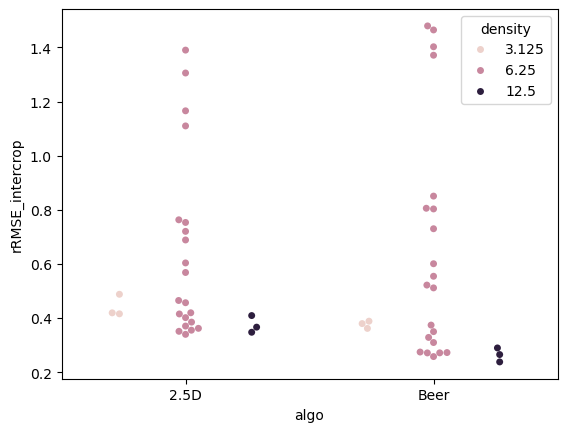

In [169]:
plot = sns.swarmplot(
    data=df_tmp,
    x="algo", 
    y="rRMSE_intercrop",
    hue="density",
    dodge=True
)

for _, point in df_tmp.iterrows():

            if point["algo"] == 'Beer' and point["design"] != 'strips':
                print(point["density"], round(point["rRMSE_intercrop"],3))
                
plt.savefig('../2-outputs/RMSE_density.png', dpi=1000)

In [145]:
rmse_3 = np.array([0.362,0.38,0.389])
rmse_6 = np.array([0.275,0.258,0.273])
rmse_12 = np.array([0.238,0.265,0.29])
print("3.125", round(rmse_3.mean(),3), round(rmse_3.std(),3))
print("6.25", round(rmse_6.mean(),3), round(rmse_6.std(),3))
print("12.5", round(rmse_12.mean(),3), round(rmse_12.std(),3))

3.125 0.377 0.011
6.25 0.269 0.008
12.5 0.264 0.021


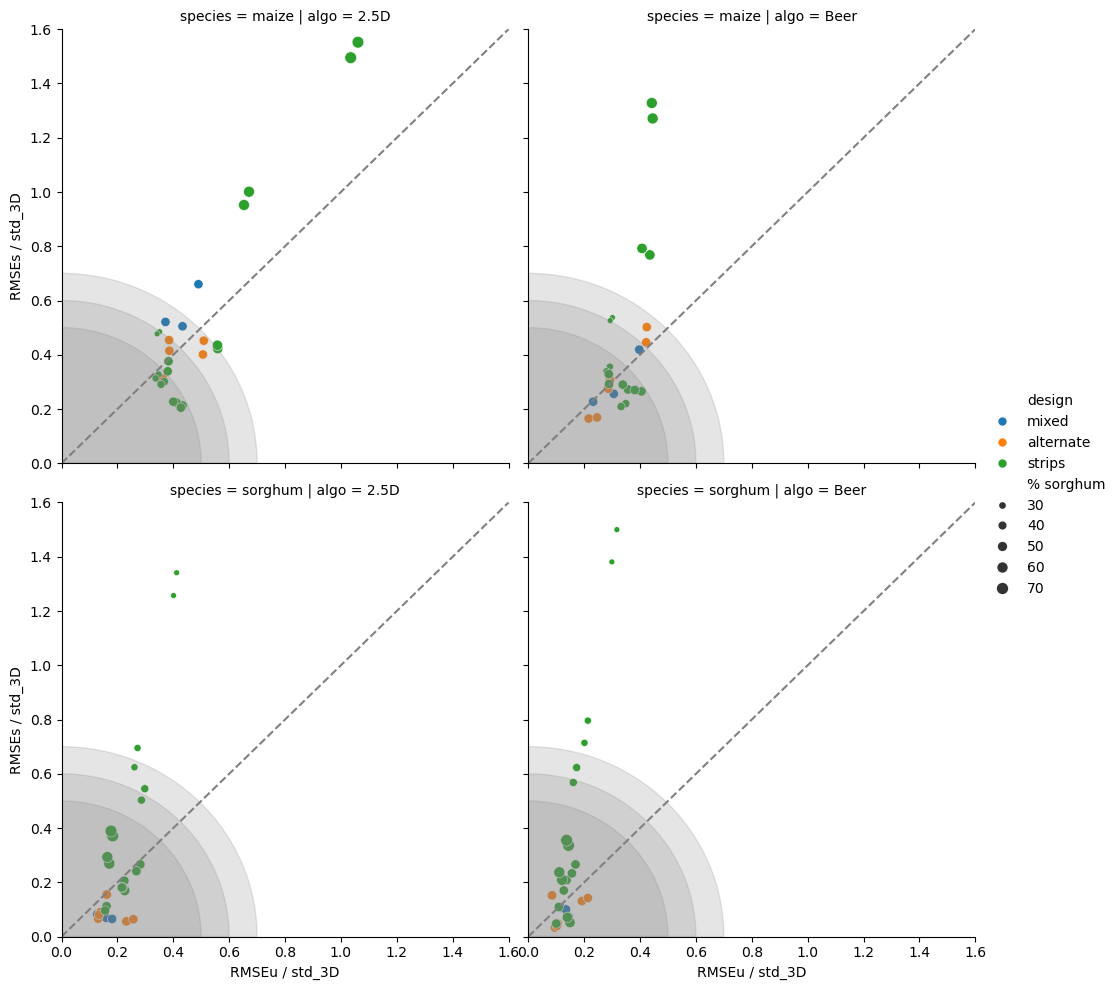

In [170]:
plot = sns.relplot(
    data=df_rrmse,
    x="RMSEu / std_3D", 
    y="RMSEs / std_3D",
    hue="design",
    row="species",
    col="algo",
    kind="scatter",
    size="% sorghum",
)

arrange_sns_plot(plot)

plot.savefig('../2-outputs/coucheney_design_prop.png')

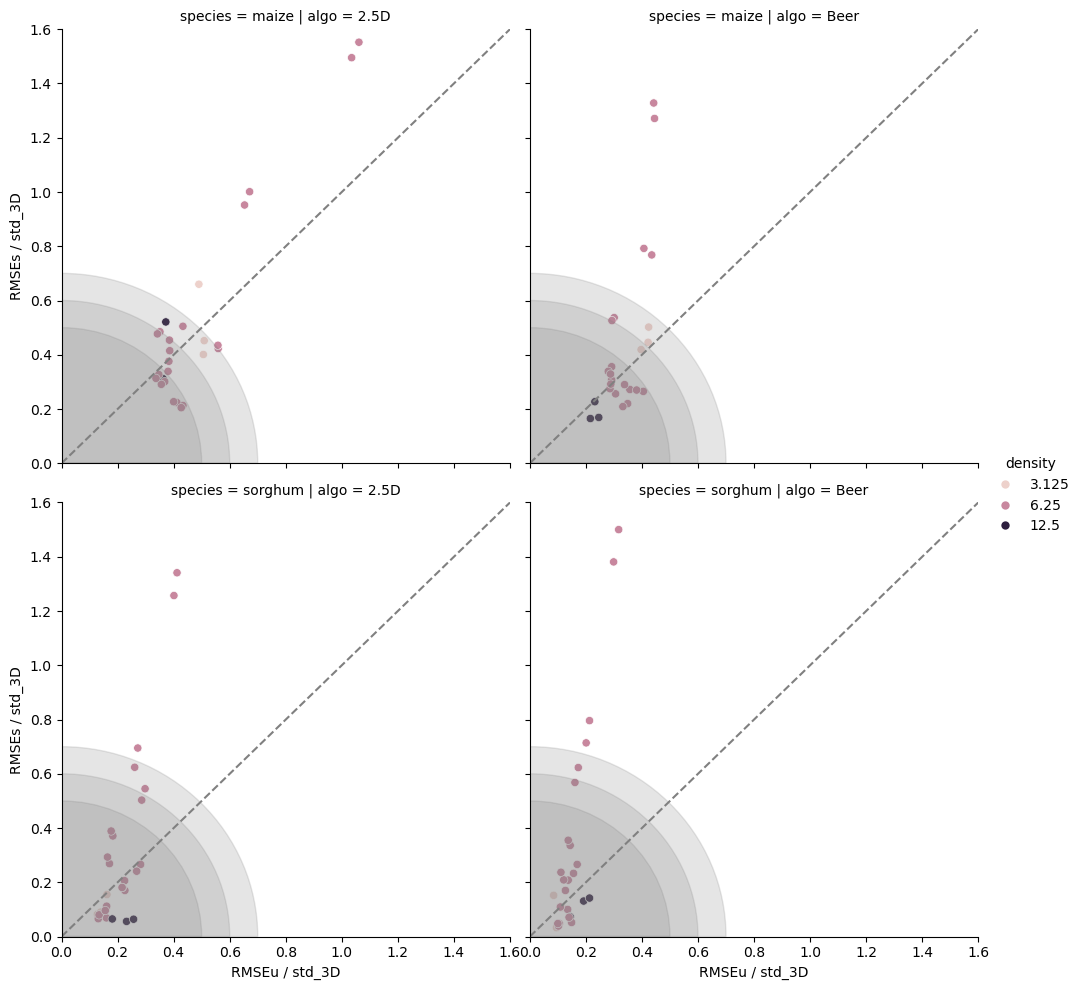

In [175]:
plot = sns.relplot(
    data=df_rrmse,
    x="RMSEu / std_3D", 
    y="RMSEs / std_3D",
    hue="density",
    row="species",
    col="algo",
    kind="scatter",
)

arrange_sns_plot(plot)

plot.savefig('../2-outputs/coucheney_density.png')

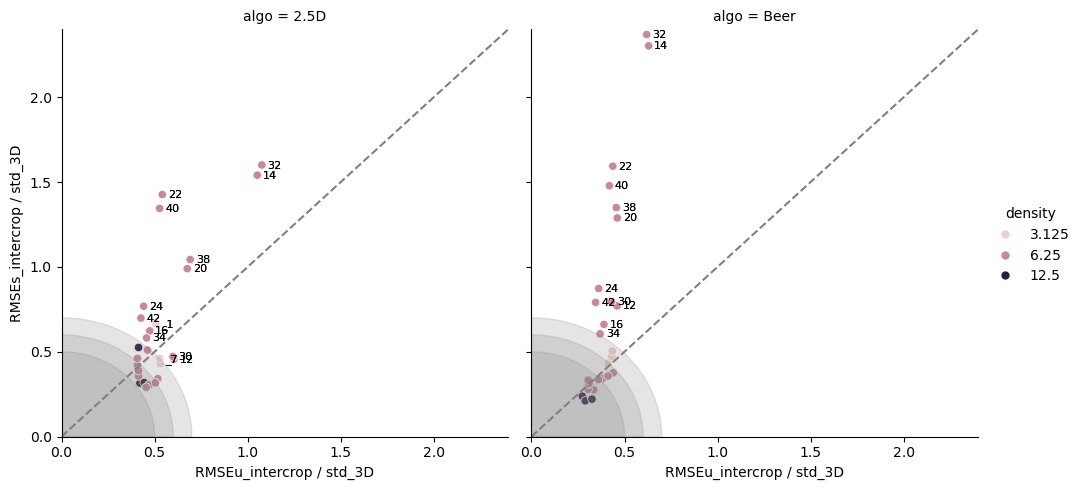

In [176]:
plot = sns.relplot(
    data=df_rrmse,
    x="RMSEu_intercrop / std_3D", 
    y="RMSEs_intercrop / std_3D",
    hue="density",
    col="algo",
    kind="scatter",
)

arrange_sns_plot(plot, 2.4, 2.4)

label_point(df_rrmse["RMSEu_intercrop / std_3D"], df_rrmse["RMSEs_intercrop / std_3D"], df_rrmse.usm, df_rrmse.algo, plot) 

plot.savefig('../2-outputs/coucheney_density_avg.png')

In [ ]:
plot = sns.relplot(
    data=df_rrmse,
    x="RMSEu_intercrop / std_3D", 
    y="RMSEs_intercrop / std_3D",
    hue="design",
    col="algo",
    kind="scatter",
    size="% sorghum",
)

arrange_sns_plot(plot, 2.4, 2.4)

label_point(df_rrmse["RMSEu_intercrop / std_3D"], df_rrmse["RMSEs_intercrop / std_3D"], df_rrmse.usm, df_rrmse.algo, plot) 

plot.savefig('../2-outputs/coucheney_design_prop_avg.png', dpi=600)

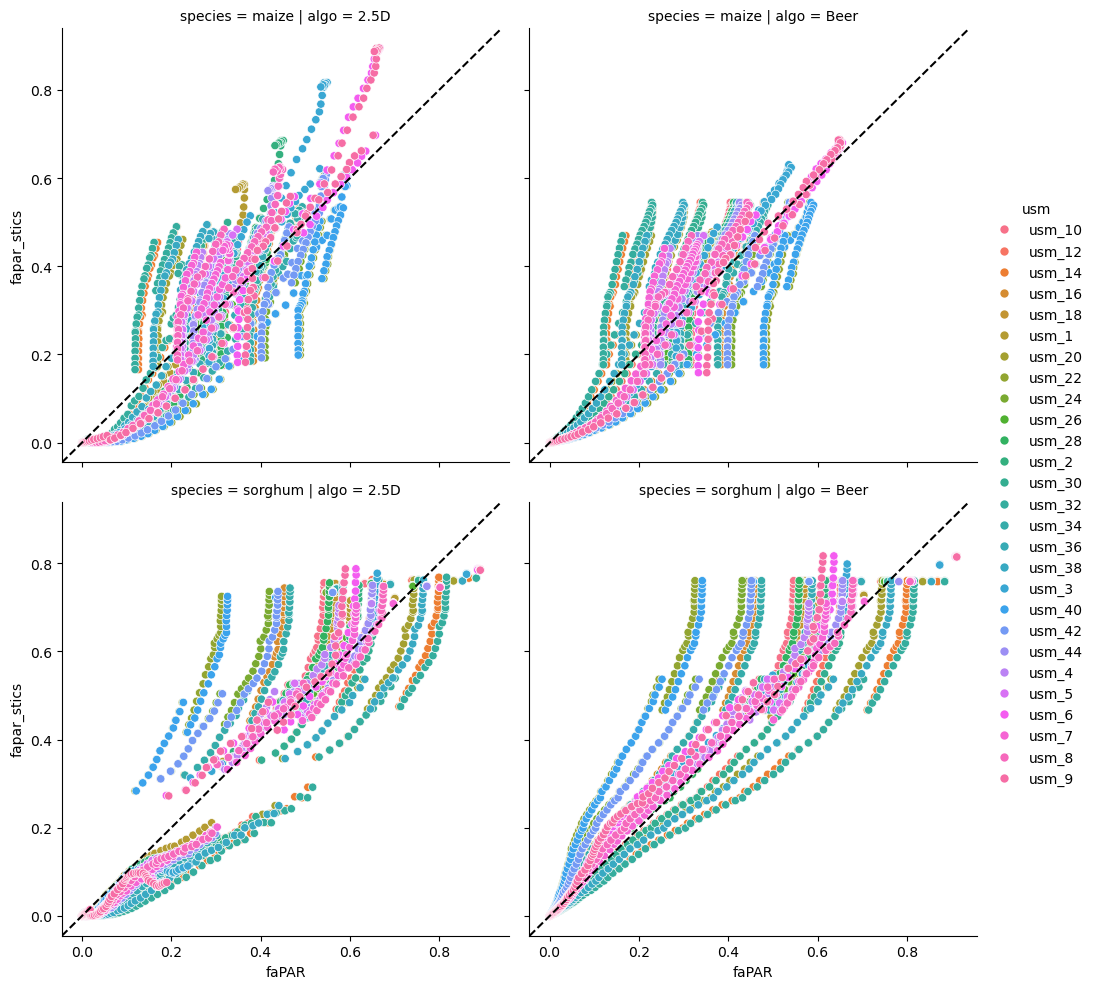

In [172]:
plot = sns.relplot(
    data=simultaneous,
    x="faPAR", 
    y="faPAR STICS",
    hue="usm",
    row="species",
    col="algo",
    kind="scatter",
)

for ax in plot.axes.flat:
    ax.axline((0, 0), slope=1, color="k", linestyle="--")

# for i, row_value in enumerate(plot.row_names):
#     for j, col_value in enumerate(plot.col_names):

#         ax = plot.axes[i, j]

#         facet_df = df[
#             (df["species"] == row_value) &
#             (df["algo"] == col_value)
#         ]

#         for curve, curve_df in facet_df.groupby("usm"):
#             curve_df = curve_df.sort_values("sum_fapar")

#             ax.plot(
#                 curve_df["sum_fapar"],
#                 curve_df["regression"],
#                 "--",
#                 alpha=0.8,
#                 color="grey"
#             )

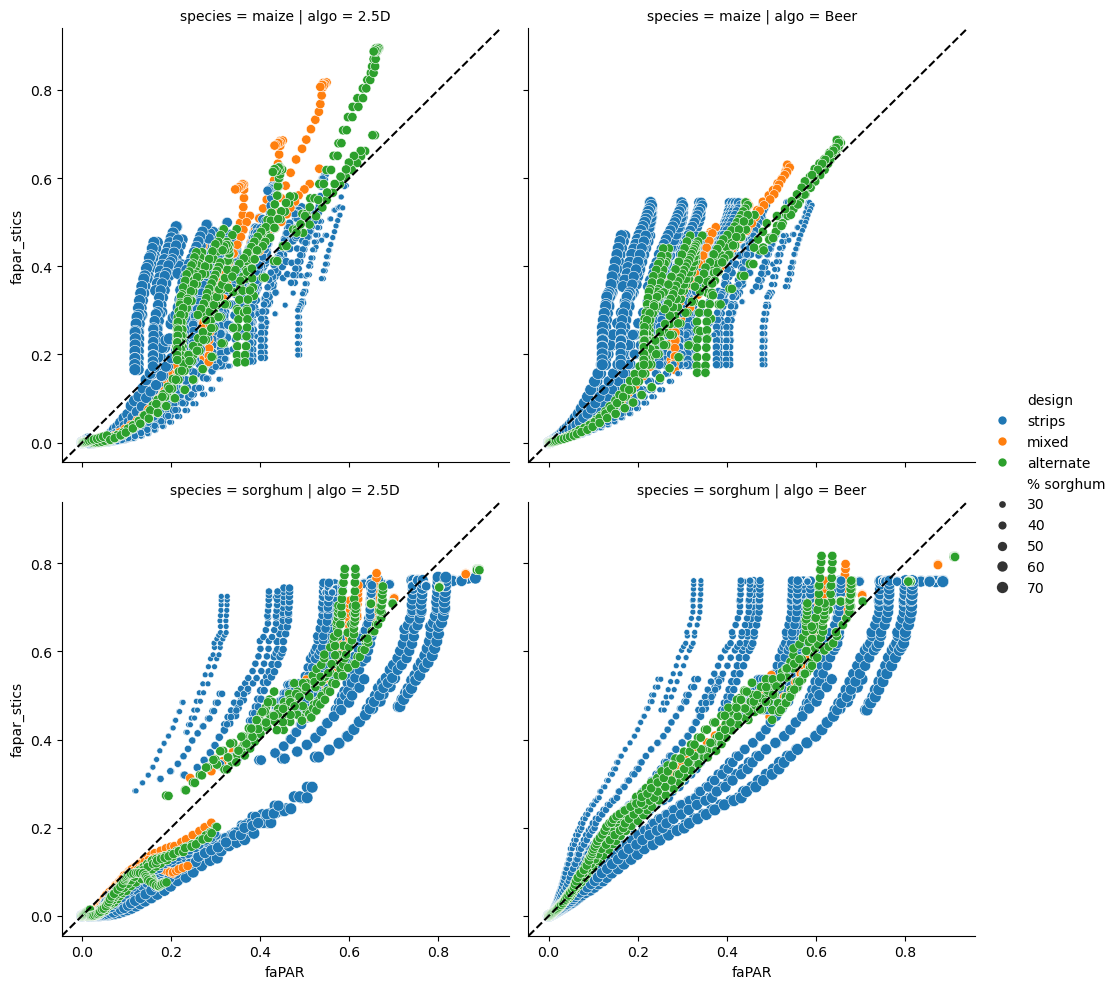

In [183]:
plot = sns.relplot(
    data=simultaneous,
    x="faPAR", 
    y="faPAR STICS",
    hue="design",
    row="species",
    col="algo",
    size="% sorghum",
    kind="scatter",
)

for ax in plot.axes.flat:
    ax.axline((0, 0), slope=1, color="k", linestyle="--")

plot.savefig('../2-outputs/fapar_3d_vs_stics_design.png')

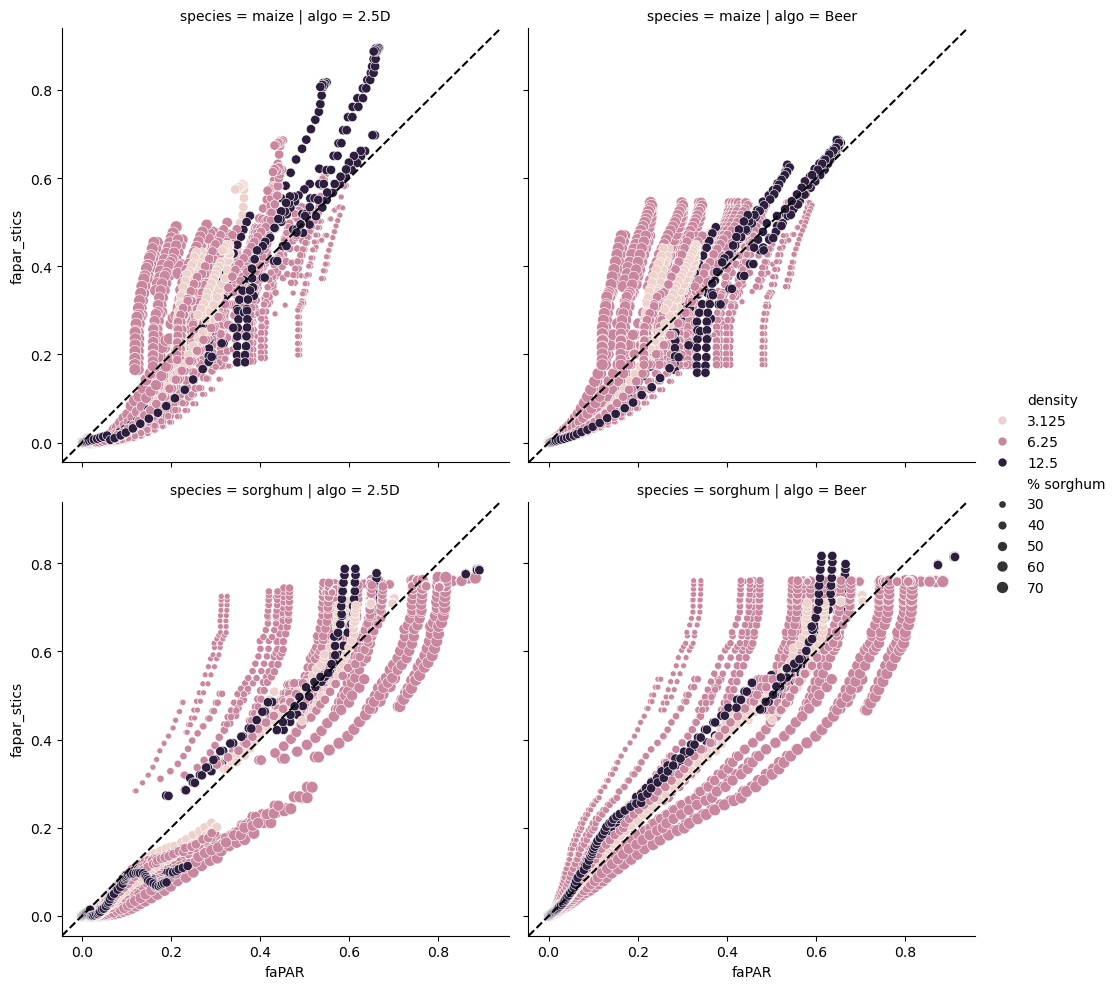

In [174]:
plot = sns.relplot(
    data=simultaneous,
    x="faPAR", 
    y="faPAR STICS",
    hue="density",
    row="species",
    col="algo",
    size="% sorghum",
    kind="scatter",
)

for ax in plot.axes.flat:
    ax.axline((0, 0), slope=1, color="k", linestyle="--")